## imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math
from scipy.linalg import inv
#oxts
from collections import namedtuple
import datetime as dt
import glob
import os
from google.colab import drive

from pathlib import Path
from typing import List, Tuple, Optional, Dict

In [2]:
drive.mount('/content/drive') #вылезет регистрация
# Путь к папке с ноутбуком
base_path = '/content/drive/MyDrive/Science work/Files'
# Чтение файла
#target = pd.read_csv(os.path.join(notebook_path, 'train_target.csv'))

ValueError: mount failed

In [ ]:
l_car = 2.5
p = l_car + 0.965

# Функции

## Filters

In [ ]:
def f_nonlinar(xt, d_t, l_car):
  xk = math.cos(xt[2,0]) * math.cos(xt[4,0]) * xt[3,0] * d_t + xt[0,0]
  yk = math.sin(xt[2,0]) * math.cos(xt[4,0]) * xt[3,0] * d_t + xt[1,0]
  teta = math.sin(xt[4,0]) * xt[3,0] * d_t / l_car + xt[2,0]

  return np.array([[xk, yk, teta, xt[3,0], xt[4,0]]]).T


def h_nonlinar(Xt, X_gps, l_off, alpha):
  xk = X_gps[0,0] - l_off * math.cos(Xt[2,0] + alpha + 0.5 * math.pi)
  yk = X_gps[1,0] - l_off * math.sin(Xt[2,0] + alpha + 0.5 * math.pi)
  teta = X_gps[2,0]

  return np.array([[xk, yk, teta]]).T

In [ ]:
def F_func(x, dt, l_car):
    """
    Вычисление матрицы Якоби для дискретной модели (11)

    Parameters:
    x: vector [x_p, y_p, theta, v_l, phi]
    dt: шаг времени
    l: длина автомобиля
    """
    x_p, y_p, theta, v_l, phi = [item.item() for item in x]
    F = np.eye(5)

    # Строка 1: ∂f₁/∂x
    F[0, 2] = -np.sin(theta) * np.cos(phi) * v_l * dt
    F[0, 3] = math.cos(theta) * math.cos(phi) * dt
    F[0, 4] = -math.cos(theta) * math.sin(phi) * v_l * dt

    # Строка 2: ∂f₂/∂x
    F[1, 2] = math.cos(theta) * math.cos(phi) * v_l * dt
    F[1, 3] = math.sin(theta) * math.cos(phi) * dt
    F[1, 4] = -math.sin(theta) * math.sin(phi) * v_l * dt

    # Строка 3: ∂f₃/∂x
    F[2, 3] = math.sin(phi) * dt / l_car
    F[2, 4] = math.cos(phi) * v_l * dt / l_car

    return F

def H_func(x, dt, l_off, alpha):
    teta = x[2].item()

    H = np.zeros((3, 5))

    H[0, 0] = 1
    H[1, 1] = 1
    H[2, 2] = 1
    H[0, 4] = l_off * math.sin(teta + alpha + 0.5 * math.pi)
    H[1, 4] = -l_off * math.cos(teta + alpha + 0.5 * math.pi)

    return H

def G_func(x0, dt):
  G = np.zeros((5, 2))
  G[0,0] = 0.5 * dt * dt * math.cos(x0[4])
  G[1,0] = 0.5 * dt * dt * math.sin(x0[4])
  G[3,0] = dt
  G[2,1] = 0.5 * dt * dt
  G[4,1] = dt
  return G

def Q_func(xt, G, beta):
  return G @ np.diag([beta[0], beta[1]]) @ G.T + np.diag(beta[2:])

def R_func(nu):
  return np.diag(nu)

In [ ]:
# Фильтр Калмана
def Extended_Kalman_filter(zs, x0, P0, beta, nu, dt=0.1, Ksi_U = np.array([0])):
  l_car = 2.71
  l_off = 0.323
  alpha = 0.154

  dim_X = x0.shape[0]
  x=np.reshape(x0, (dim_X, 1))
  xf = []
  P=P0.copy()
  G = G_func(x0, dt)
  m = 3

  k=0
  for zk in zs:
      x[3,0] = zk[3]
      x[4,0] = zk[4]
      xf.append(x.reshape(dim_X))

      Fk = F_func(x, dt, l_car)
      Qk = Q_func(x, G, beta)
      Rk = R_func(nu)
      Ge_k = np.eye(P0.shape[0]) #####?

      # Prediction Module
      xk_k1 = f_nonlinar(x, dt, l_car)
      Pk_k1 = Fk @ P @ Fk.T + Ge_k @ Qk @ Ge_k.T

      # Measurement Prediction Module тут сомнительно
      Hk = H_func(xk_k1, dt, l_off, alpha)
      zk = (zk[:3]).reshape((m,1))
      y = zk - h_nonlinar(xk_k1, zk, l_off, alpha)
      S = Hk @ Pk_k1 @ Hk.T + Rk

      # Update Module
      K = Pk_k1 @ Hk.T @ inv(S)

      x = xk_k1 + K @ y
      P = Pk_k1 - K @ Hk @ Pk_k1
      k+=1

  return xf

## armse

In [ ]:
def calculate_ARMSE_n_dim(true_states, fil_states):
    """
    Calculate ARMSE (Average Root Mean Square Error) for n-dimensional states

    Parameters:
    true_states: array of true states (N, dim)
    fil_states: array of filtered states (N, dim)

    Returns:
    ARMSE: scalar - norm of all component-wise ARMSEs
    armse_components: array - ARMSE for each component
    """
    errors = true_states - fil_states  # форма: (N, dim)

    # ARMSE для каждой компоненты
    armse_components = np.sqrt(np.mean(errors**2, axis=0))

    # Общий ARMSE (норма вектора компонентных ARMSE)
    ARMSE = np.linalg.norm(armse_components)

    return ARMSE, armse_components

def calculate_ARMSE_xy(true_states, fil_states):
    """
    Calculate combined ARMSE for x and y components only
    """
    errors_xy = true_states[:, :2] - fil_states[:, :2]  # Берем только x и y

    # ARMSE для x и y отдельно
    armse_x = np.sqrt(np.mean(errors_xy[:, 0]**2))
    armse_y = np.sqrt(np.mean(errors_xy[:, 1]**2))

    # Комбинированный ARMSE для x и y
    armse_xy = np.sqrt(armse_x**2 + armse_y**2)

    return armse_xy, armse_x, armse_y

## visual

In [ ]:
def plot_kalman_results(true_history, filtered_history, dt, N):
    """
    Построение графиков компонент вектора состояния и траектории x-y
    с сравнением истинных и отфильтрованных значений

    Parameters:
    true_history - история истинного вектора состояния (массив размером N x n)
    filtered_history - история отфильтрованного вектора состояния (массив размером N x n)
    dt - шаг дискретизации
    N - количество шагов
    """

    # Создаем временную ось
    time = np.arange(0, N * dt, dt)

    # Проверяем количество компонент
    n_components = true_history.shape[1]

    # Создаем фигуру с подграфиками - 3x2 для 5 компонент + траектория
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))

    # График первой компоненты (x)
    axes[0, 0].plot(time, true_history[:, 0], 'b-', linewidth=2, label='Истинный x')
    axes[0, 0].plot(time, filtered_history[:, 0], 'r--', linewidth=2, label='Фильтр x')
    axes[0, 0].set_xlabel('Время, с')
    axes[0, 0].set_ylabel('x, м')
    axes[0, 0].set_title('Координата X')
    axes[0, 0].grid(True)
    axes[0, 0].legend()

    # График второй компоненты (y)
    axes[0, 1].plot(time, true_history[:, 1], 'b-', linewidth=2, label='Истинный y')
    axes[0, 1].plot(time, filtered_history[:, 1], 'r--', linewidth=2, label='Фильтр y')
    axes[0, 1].set_xlabel('Время, с')
    axes[0, 1].set_ylabel('y, м')
    axes[0, 1].set_title('Координата Y')
    axes[0, 1].grid(True)
    axes[0, 1].legend()

    # График третьей компоненты (theta - угол курса)
    axes[1, 0].plot(time, true_history[:, 2], 'b-', linewidth=2, label='Истинный theta')
    axes[1, 0].plot(time, filtered_history[:, 2], 'r--', linewidth=2, label='Фильтр theta')
    axes[1, 0].set_xlabel('Время, с')
    axes[1, 0].set_ylabel('theta, рад')
    axes[1, 0].set_title('Угол курса (theta)')
    axes[1, 0].grid(True)
    axes[1, 0].legend()

    # График четвертой компоненты (v - линейная скорость)
    axes[1, 1].plot(time, true_history[:, 3], 'b-', linewidth=2, label='Истинный v')
    axes[1, 1].plot(time, filtered_history[:, 3], 'r--', linewidth=2, label='Фильтр v')
    axes[1, 1].set_xlabel('Время, с')
    axes[1, 1].set_ylabel('v, м/с')
    axes[1, 1].set_title('Линейная скорость (v)')
    axes[1, 1].grid(True)
    axes[1, 1].legend()

    # График пятой компоненты (phi - угол фи)
    axes[2, 0].plot(time, true_history[:, 4], 'b-', linewidth=2, label='Истинный phi')
    axes[2, 0].plot(time, filtered_history[:, 4], 'r--', linewidth=2, label='Фильтр phi')
    axes[2, 0].set_xlabel('Время, с')
    axes[2, 0].set_ylabel('phi, рад')
    axes[2, 0].set_title('Угол фи (phi)')
    axes[2, 0].grid(True)
    axes[2, 0].legend()

    # График траектории x-y
    axes[2, 1].plot(true_history[:, 0], true_history[:, 1], 'b-', linewidth=2, label='Истинная траектория')
    axes[2, 1].plot(filtered_history[:, 0], filtered_history[:, 1], 'r--', linewidth=2, label='Фильтр траектория')
    axes[2, 1].plot(true_history[0, 0], true_history[0, 1], 'go', markersize=8, label='Начало')
    axes[2, 1].plot(true_history[-1, 0], true_history[-1, 1], 'ro', markersize=8, label='Конец')
    axes[2, 1].set_xlabel('x, м')
    axes[2, 1].set_ylabel('y, м')
    axes[2, 1].set_title('Траектория движения (x-y)')
    axes[2, 1].grid(True)
    axes[2, 1].legend()
    axes[2, 1].axis('equal')

    plt.tight_layout()
    plt.show()

## функции 2

### poses

In [ ]:
def load_poses_to_xy(base_path, sequence_num):
    """
    Загружает poses из файла KITTI odometry и извлекает координаты x, y.

    Args:
        base_path (str): Базовый путь к данным
        sequence_num (str или int): Номер последовательности (00, 01, ..., 21)

    Returns:
        tuple: (x_coords, y_coords) - массивы координат x и y
    """
    # Форматируем номер последовательности в двузначный формат
    if isinstance(sequence_num, int):
        sequence_num = f"{sequence_num:02d}"
    elif isinstance(sequence_num, str) and len(sequence_num) == 1:
        sequence_num = f"0{sequence_num}"

    # Формируем путь к файлу
    poses_dir = os.path.join(base_path, 'poses')
    file_path = os.path.join(poses_dir, f"{sequence_num}.txt")

    # Проверяем существование файла
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Файл не найден: {file_path}")

    # Читаем файл
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Инициализируем массивы для координат
    x_coords = []
    y_coords = []

    # Парсим каждую строку
    for line_num, line in enumerate(lines):
        line = line.strip()
        if not line:
            continue

        # Разбиваем строку на 12 чисел
        numbers = list(map(float, line.split()))

        if len(numbers) != 12:
            print(f"Предупреждение: строка {line_num} содержит {len(numbers)} чисел вместо 12")
            continue

        # Преобразуем в матрицу 3x4
        # Формат: [r11, r12, r13, tx, r21, r22, r23, ty, r31, r32, r33, tz]
        pose_matrix_3x4 = np.array(numbers).reshape(3, 4)

        # Извлекаем координаты x, y из трансляционной части (столбец 4)
        x = pose_matrix_3x4[0, 3]  # tx
        y = pose_matrix_3x4[1, 3]  # ty

        x_coords.append(x)
        y_coords.append(y)

    print(f"Загружено {len(x_coords)} поз из последовательности {sequence_num}")
    return np.array(x_coords), np.array(y_coords)

In [ ]:
def load_poses_to_xy_with_info(base_path, sequence_num):
    """
    Загружает poses и возвращает координаты + дополнительную информацию.
    """
    if isinstance(sequence_num, int):
        sequence_num = f"{sequence_num:02d}"
    elif isinstance(sequence_num, str) and len(sequence_num) == 1:
        sequence_num = f"0{sequence_num}"

    poses_dir = os.path.join(base_path, 'poses')
    file_path = os.path.join(poses_dir, f"{sequence_num}.txt")

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Файл не найден: {file_path}")

    with open(file_path, 'r') as f:
        lines = f.readlines()

    x_coords = []
    y_coords = []
    z_coords = []
    full_poses = []  # Полные матрицы 3x4

    for line in lines:
        line = line.strip()
        if not line:
            continue

        numbers = list(map(float, line.split()))

        if len(numbers) != 12:
            continue

        pose_matrix_3x4 = np.array(numbers).reshape(3, 4)

        x = pose_matrix_3x4[0, 3]  # tx
        y = pose_matrix_3x4[1, 3]  # ty
        z = pose_matrix_3x4[2, 3]  # tz

        x_coords.append(x)
        y_coords.append(y)
        z_coords.append(z)
        full_poses.append(pose_matrix_3x4)

    result = {
        'x': np.array(x_coords),
        'y': np.array(y_coords),
        'z': np.array(z_coords),
        'poses': np.array(full_poses),
        'sequence': sequence_num,
        'num_frames': len(x_coords)
    }

    print(f"Загружено {result['num_frames']} поз из последовательности {sequence_num}")
    return result

In [ ]:
# Функция для загрузки нескольких последовательностей
def load_multiple_sequences(base_path, sequence_nums):
    """
    Загружает несколько последовательностей.

    Args:
        base_path (str): Базовый путь
        sequence_nums (list): Список номеров последовательностей [0, 1, 2, ...]

    Returns:
        dict: Словарь с данными для каждой последовательности
    """
    sequences_data = {}

    for seq_num in sequence_nums:
        try:
            data = load_poses_to_xy_with_info(base_path, seq_num)
            sequences_data[data['sequence']] = data
        except FileNotFoundError as e:
            print(f"Пропуск последовательности {seq_num}: {e}")
            continue

    print(f"Успешно загружено {len(sequences_data)} последовательностей")
    return sequences_data

### визуализация

In [ ]:
def plot_vehicle_states_custom(states_array, y_scale_factors=None):
    """Визуализация с настраиваемым масштабом по Y для каждого графика."""
    if y_scale_factors is None:
        y_scale_factors = {
            'trajectory': 2.0, 'heading': 1.2, 'speed': 1.3,
            'steering': 1.5, 'coordinates': 1.2
        }

    time = np.arange(len(states_array)) * 0.1

    # Увеличиваем количество графиков до 6 (добавили координаты X и Y по времени)
    num_plots = min(states_array.shape[1] + 2, 6)  # +2 для отдельных графиков координат
    rows = (num_plots + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(16, 6 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if num_plots > 1 else [[axes]]

    plot_idx = 0

    # 1. Траектория (X-Y)
    if plot_idx < len(axes):
        ax = axes[plot_idx]
        x, y = states_array[:, 0], states_array[:, 1]
        ax.plot(x, y, 'b-', linewidth=2.5)
        ax.plot(x[0], y[0], 'go', markersize=8, label='Старт')
        ax.plot(x[-1], y[-1], 'ro', markersize=8, label='Финиш')

        # Применяем масштабирование по Y
        x_center, y_center = (np.max(x) + np.min(x)) / 2, (np.max(y) + np.min(y)) / 2
        x_range, y_range = np.max(x) - np.min(x), np.max(y) - np.min(y)
        scale = y_scale_factors['trajectory']

        ax.set_xlim([x_center - x_range/2, x_center + x_range/2])
        ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('X координата (м)')
        ax.set_ylabel('Y координата (м)')
        ax.set_title(f'Траектория движения (масштаб Y: {scale}x)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 2. Координата X во времени
    if plot_idx < len(axes):
        ax = axes[plot_idx]
        x_coords = states_array[:, 0]
        ax.plot(time, x_coords, 'r-', linewidth=2, label='X координата')

        # Масштабирование по Y
        y_range = np.max(x_coords) - np.min(x_coords)
        if y_range > 0:
            y_center = (np.max(x_coords) + np.min(x_coords)) / 2
            scale = y_scale_factors['coordinates']
            ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('X координата (м)')
        ax.set_title('Координата X во времени')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 3. Координата Y во времени
    if plot_idx < len(axes):
        ax = axes[plot_idx]
        y_coords = states_array[:, 1]
        ax.plot(time, y_coords, 'b-', linewidth=2, label='Y координата')

        # Масштабирование по Y
        y_range = np.max(y_coords) - np.min(y_coords)
        if y_range > 0:
            y_center = (np.max(y_coords) + np.min(y_coords)) / 2
            scale = y_scale_factors['coordinates']
            ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('Y координата (м)')
        ax.set_title('Координата Y во времени')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 4. Курс
    if plot_idx < len(axes) and states_array.shape[1] > 2:
        ax = axes[plot_idx]
        heading_deg = np.degrees(states_array[:, 2])
        ax.plot(time, heading_deg, 'g-', linewidth=2)

        # Масштабирование по Y
        y_range = np.max(heading_deg) - np.min(heading_deg)
        if y_range > 0:
            y_center = (np.max(heading_deg) + np.min(heading_deg)) / 2
            scale = y_scale_factors['heading']
            ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('Курс (°)')
        ax.set_title('Угол курса')
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 5. Скорость
    if plot_idx < len(axes) and states_array.shape[1] > 3:
        ax = axes[plot_idx]
        speed_kmh = states_array[:, 3] * 3.6
        ax.plot(time, speed_kmh, 'orange', linewidth=2)

        # Масштабирование по Y
        y_range = np.max(speed_kmh) - np.min(speed_kmh)
        if y_range > 0:
            y_center = (np.max(speed_kmh) + np.min(speed_kmh)) / 2
            scale = y_scale_factors['speed']
            ax.set_ylim([max(0, y_center - y_range/2 * scale), y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('Скорость (км/ч)')
        ax.set_title('Скорость движения')
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 6. Угол поворота
    if plot_idx < len(axes) and states_array.shape[1] > 4:
        ax = axes[plot_idx]
        steering_deg = np.degrees(states_array[:, 4])
        ax.plot(time, steering_deg, 'm-', linewidth=2)

        # Масштабирование по Y
        y_range = np.max(steering_deg) - np.min(steering_deg)
        if y_range > 0:
            y_center = (np.max(steering_deg) + np.min(steering_deg)) / 2
            scale = y_scale_factors['steering']
            ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('Угол поворота (°)')
        ax.set_title('Угол поворота руля')
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # Скрываем пустые subplots
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_trajectory_comparison(controls_array, trajectory_array, title="Сравнение траекторий"):
    """
    Визуализирует сравнение траекторий из controls_array и trajectory_array

    Parameters:
    -----------
    controls_array : numpy.ndarray shape (n, 5)
        Исходный массив, первые две компоненты - x, y
    trajectory_array : numpy.ndarray shape (n, 3)
        Моделируемый массив траектории [x, y, theta]
    """

    # Создаем 4 отдельных графика
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    time = np.arange(controls_array.shape[0])

    # График 1: Траектории в XY-плоскости
    ax1.plot(controls_array[:, 0], controls_array[:, 1], 'b-', linewidth=2, label='Controls траектория')
    ax1.plot(trajectory_array[:, 0], trajectory_array[:, 1], 'r--', linewidth=2, label='Model траектория')
    ax1.plot(controls_array[0, 0], controls_array[0, 1], 'go', markersize=8, label='Start')
    ax1.plot(controls_array[-1, 0], controls_array[-1, 1], 'ro', markersize=8, label='End (Controls)')
    ax1.plot(trajectory_array[-1, 0], trajectory_array[-1, 1], 'mo', markersize=8, label='End (Model)')
    ax1.set_xlabel('X (м)')
    ax1.set_ylabel('Y (м)')
    ax1.set_title('Сравнение траекторий в XY-плоскости')
    ax1.legend()
    ax1.grid(True)
    ax1.axis('equal')

    # График 2: Сравнение координат X
    ax2.plot(time, controls_array[:, 0], 'b-', linewidth=2, label='Controls X')
    ax2.plot(time, trajectory_array[:, 0], 'r--', linewidth=2, label='Model X')
    ax2.set_xlabel('Время (шаги)')
    ax2.set_ylabel('X координата (м)')
    ax2.set_title('Сравнение координат X')
    ax2.legend()
    ax2.grid(True)

    # График 3: Сравнение координат Y
    ax3.plot(time, controls_array[:, 1], 'b-', linewidth=2, label='Controls Y')
    ax3.plot(time, trajectory_array[:, 1], 'r--', linewidth=2, label='Model Y')
    ax3.set_xlabel('Время (шаги)')
    ax3.set_ylabel('Y координата (м)')
    ax3.set_title('Сравнение координат Y')
    ax3.legend()
    ax3.grid(True)

    # График 4: Сравнение углов theta
    # Предполагаем, что в controls_array theta может быть в 3-м столбце (индекс 2)
    if controls_array.shape[1] >= 3:
        ax4.plot(time, np.degrees(controls_array[:, 2]), 'b-', linewidth=2, label='Controls θ')
    ax4.plot(time, np.degrees(trajectory_array[:, 2]), 'r--', linewidth=2, label='Model θ')
    ax4.set_xlabel('Время (шаги)')
    ax4.set_ylabel('Угол θ (градусы)')
    ax4.set_title('Сравнение углов ориентации θ')
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout()
    plt.show()

    # Вычисляем метрики ошибок
    print("="*50)
    print("МЕТРИКИ СРАВНЕНИЯ ТРАЕКТОРИЙ")
    print("="*50)

    # RMSE для координат
    rmse_x = np.sqrt(np.mean((controls_array[:, 0] - trajectory_array[:, 0])**2))
    rmse_y = np.sqrt(np.mean((controls_array[:, 1] - trajectory_array[:, 1])**2))

    print(f"RMSE по X: {rmse_x:.4f} м")
    print(f"RMSE по Y: {rmse_y:.4f} м")
    print(f"Общий RMSE: {np.sqrt(rmse_x**2 + rmse_y**2):.4f} м")

    # Максимальные ошибки
    max_error_x = np.max(np.abs(controls_array[:, 0] - trajectory_array[:, 0]))
    max_error_y = np.max(np.abs(controls_array[:, 1] - trajectory_array[:, 1]))

    print(f"Максимальная ошибка по X: {max_error_x:.4f} м")
    print(f"Максимальная ошибка по Y: {max_error_y:.4f} м")

    # Сравнение конечных позиций
    final_pos_controls = controls_array[-1, :2]
    final_pos_model = trajectory_array[-1, :2]
    final_distance = np.linalg.norm(final_pos_controls - final_pos_model)

    print(f"Конечная позиция Controls: ({final_pos_controls[0]:.2f}, {final_pos_controls[1]:.2f}) м")
    print(f"Конечная позиция Model:    ({final_pos_model[0]:.2f}, {final_pos_model[1]:.2f}) м")
    print(f"Расстояние между конечными точками: {final_distance:.4f} м")

In [ ]:
def plot_all_poses(all_seq, cols=2, fig_width=15, fig_height_per_row=5, y_scale=1.5):
    """
    Рисует траектории (y от x) для всех последовательностей в виде сетки графиков.

    Parameters:
    -----------
    all_seq : dict
        Словарь с данными последовательностей (результат load_multiple_sequences)
    cols : int
        Количество графиков в строке (по умолчанию 2)
    fig_width : float
        Ширина всей фигуры
    fig_height_per_row : float
        Высота на каждый ряд графиков
    y_scale : float
        Коэффициент увеличения масштаба по оси Y
    """
    n_sequences = len(all_seq)
    rows = (n_sequences + cols - 1) // cols

    # Размер фигуры
    fig_height = rows * fig_height_per_row
    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height))

    # Преобразуем axes в плоский массив для удобства
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.reshape(-1)
    else:
        axes = axes.flatten()

    # Проходим по всем последовательностям
    for idx, (seq_name, seq_data) in enumerate(all_seq.items()):
        ax = axes[idx]

        x_coords = seq_data['x']
        y_coords = seq_data['y']

        # Строим траекторию
        ax.plot(x_coords, y_coords, 'b-', linewidth=2)

        # Настройки графика
        ax.set_title(f'Sequence {seq_name} (Frames: {len(x_coords)})', fontsize=12, fontweight='bold')
        ax.set_xlabel('X coordinate (m)', fontsize=10)
        ax.set_ylabel('Y coordinate (m)', fontsize=10)
        ax.grid(True, alpha=0.3)

        # Увеличиваем масштаб по Y
        y_min, y_max = y_coords.min(), y_coords.max()
        y_range = y_max - y_min

        # Добавляем отступы и увеличиваем масштаб
        if y_range == 0:
            # Если все y одинаковые
            ax.set_ylim(y_min - 1, y_max + 1)
        else:
            y_padding = y_range * 0.1 * y_scale  # 10% от диапазона, умноженное на коэффициент
            ax.set_ylim(y_min - y_padding, y_max + y_padding)

        # Для сохранения пропорций можно раскомментировать:
        # ax.axis('equal')

    # Скрываем пустые оси
    for empty_idx in range(len(all_seq), len(axes)):
        axes[empty_idx].set_visible(False)

    # Общий заголовок
    plt.suptitle('Vehicle Trajectories (Y vs X)', fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()


### gps/imu

In [ ]:
"""Provides helper methods for loading and parsing KITTI OXTS data."""
# Per dataformat.txt
OxtsPacket = namedtuple('OxtsPacket',
                        'lat, lon, alt, ' +
                        'roll, pitch, yaw, ' +
                        'vn, ve, vf, vl, vu, ' +
                        'ax, ay, az, af, al, au, ' +
                        'wx, wy, wz, wf, wl, wu, ' +
                        'pos_accuracy, vel_accuracy, ' +
                        'navstat, numsats, ' +
                        'posmode, velmode, orimode')

# Bundle into an easy-to-access structure
OxtsData = namedtuple('OxtsData', 'packet, T_w_imu')

__author__ = "Lee Clement"
__email__ = "lee.clement@robotics.utias.utoronto.ca"



def subselect_files(files, indices):
    """Subselect files by indices."""
    try:
        files = [files[i] for i in indices]
    except:
        pass
    return files


def rotx(t):
    """Rotation about the x-axis."""
    c = np.cos(t)
    s = np.sin(t)
    return np.array([[1,  0,  0],
                     [0,  c, -s],
                     [0,  s,  c]])


def roty(t):
    """Rotation about the y-axis."""
    c = np.cos(t)
    s = np.sin(t)
    return np.array([[c,  0,  s],
                     [0,  1,  0],
                     [-s, 0,  c]])


def rotz(t):
    """Rotation about the z-axis."""
    c = np.cos(t)
    s = np.sin(t)
    return np.array([[c, -s,  0],
                     [s,  c,  0],
                     [0,  0,  1]])


def transform_from_rot_trans(R, t):
    """Transformation matrix from rotation matrix and translation vector."""
    R = R.reshape(3, 3)
    t = t.reshape(3, 1)
    return np.vstack((np.hstack([R, t]), [0, 0, 0, 1]))


def read_calib_file(filepath):
    """Read in a calibration file and parse into a dictionary."""
    data = {}

    with open(filepath, 'r') as f:
        for line in f.readlines():
            try:
                key, value = line.split(':', 1)
            except ValueError:
                key, value = line.split(' ', 1)
            # The only non-float values in these files are dates, which
            # we don't care about anyway
            try:
                data[key] = np.array([float(x) for x in value.split()])
            except ValueError:
                pass

    return data


def pose_from_oxts_packet(packet, scale):
    """Helper method to compute a SE(3) pose matrix from an OXTS packet."""
    er = 6378137.  # earth radius (approx.) in meters

    # Use a Mercator projection to get the translation vector
    tx = scale * packet.lon * np.pi * er / 180.
    ty = scale * er * np.log(np.tan((90. + packet.lat) * np.pi / 360.))
    tz = packet.alt
    t = np.array([tx, ty, tz])

    # Use the Euler angles to get the rotation matrix
    Rx = rotx(packet.roll)
    Ry = roty(packet.pitch)
    Rz = rotz(packet.yaw)
    R = Rz.dot(Ry.dot(Rx))

    # Combine the translation and rotation into a homogeneous transform
    return R, t


def load_oxts_packets_and_poses(oxts_files):
    """Generator to read OXTS ground truth data.

       Poses are given in an East-North-Up coordinate system
       whose origin is the first GPS position.
    """
    # Scale for Mercator projection (from first lat value)
    scale = None
    # Origin of the global coordinate system (first GPS position)
    origin = None

    oxts = []

    for filename in oxts_files:
        with open(filename, 'r') as f:
            for line in f.readlines():
                line = line.split()
                # Last five entries are flags and counts
                line[:-5] = [float(x) for x in line[:-5]]
                line[-5:] = [int(float(x)) for x in line[-5:]]

                packet = OxtsPacket(*line)

                if scale is None:
                    scale = np.cos(packet.lat * np.pi / 180.)

                R, t = pose_from_oxts_packet(packet, scale)

                if origin is None:
                    origin = t

                T_w_imu = transform_from_rot_trans(R, t - origin)

                oxts.append(OxtsData(packet, T_w_imu))

    return oxts


class KittiOxtsLoader:
    """Load and parse KITTI OXTS data into a usable format."""

    def __init__(self, base_path, date, drive, **kwargs):
        """Set the path and pre-load OXTS data and timestamps."""
        self.dataset = kwargs.get('dataset', 'sync')
        self.drive = date + '_drive_' + drive + '_' + self.dataset
        self.data_path = os.path.join(base_path, self.drive)
        self.frames = kwargs.get('frames', None)

        # Find all the data files
        self._get_file_lists()

        # Pre-load data
        self._load_timestamps()
        self._load_oxts()

    def __len__(self):
        """Return the number of frames loaded."""
        return len(self.timestamps)

    def _get_file_lists(self):
        """Find and list OXTS data files."""
        self.oxts_files = sorted(glob.glob(
            os.path.join(self.data_path, 'oxts', 'data', '*.txt')))

        # Subselect the chosen range of frames, if any
        if self.frames is not None:
            self.oxts_files = subselect_files(self.oxts_files, self.frames)

    def _load_timestamps(self):
        """Load timestamps from file."""
        timestamp_file = os.path.join(
            self.data_path, 'oxts', 'timestamps.txt')

        # Read and parse the timestamps
        self.timestamps = []
        with open(timestamp_file, 'r') as f:
            for line in f.readlines():
                # NB: datetime only supports microseconds, but KITTI timestamps
                # give nanoseconds, so need to truncate last 4 characters to
                # get rid of \n (counts as 1) and extra 3 digits
                t = dt.datetime.strptime(line[:-4], '%Y-%m-%d %H:%M:%S.%f')
                self.timestamps.append(t)

        # Subselect the chosen range of frames, if any
        if self.frames is not None:
            self.timestamps = [self.timestamps[i] for i in self.frames]

    def _load_oxts(self):
        """Load OXTS data from file."""
        self.oxts = load_oxts_packets_and_poses(self.oxts_files)

    def get_oxts_packet(self, idx):
        """Get OXTS packet at the specified index."""
        return self.oxts[idx].packet

    def get_pose(self, idx):
        """Get pose matrix at the specified index."""
        return self.oxts[idx].T_w_imu

    def get_timestamp(self, idx):
        """Get timestamp at the specified index."""
        return self.timestamps[idx]

    @property
    def packets(self):
        """Generator to yield OXTS packets."""
        for oxts_data in self.oxts:
            yield oxts_data.packet

    @property
    def poses(self):
        """Generator to yield pose matrices."""
        for oxts_data in self.oxts:
            yield oxts_data.T_w_imu

    def get_all_packets(self):
        """Get all OXTS packets as a list."""
        return [oxts_data.packet for oxts_data in self.oxts]

    def get_all_poses(self):
        """Get all pose matrices as a list."""
        return [oxts_data.T_w_imu for oxts_data in self.oxts]

    def get_translation(self, idx):
        """Get translation vector [x, y, z] at the specified index."""
        pose = self.get_pose(idx)
        return pose[0:3, 3]

    def get_rotation(self, idx):
        """Get rotation matrix 3x3 at the specified index."""
        pose = self.get_pose(idx)
        return pose[0:3, 0:3]

    def get_position(self, idx):
        """Get position coordinates [x, y, z] (alias for get_translation)."""
        return self.get_translation(idx)

In [ ]:
def extract_vehicle_state49b(loader, idx, wheelbase=2.71):
    """
    Извлекает вектор состояния X = [xk, yk, θk, vk, φk] из OXTS данных.

    Args:
        loader: KittiOxtsLoader instance
        idx: индекс кадра
        wheelbase: колесная база автомобиля в метрах (для Passat B6 = 2.71 м)

    Returns:
        dict: вектор состояния и дополнительные параметры
    """
    # Получаем данные
    packet = loader.get_oxts_packet(idx)
    pose = loader.get_pose(idx)

    # Основной вектор состояния
    xk = pose[0, 3]    # x координата (восток)
    yk = pose[1, 3]    # y координата (север)
    θk = packet.yaw    # курс (heading) в радианах
    vk = packet.vf     # линейная скорость вперед (м/с)

    # ВЫЧИСЛЕНИЕ УГЛА ПОВОРОТА РУЛЯ φk

    if idx + 1 < len(loader):
        next_pose = loader.get_pose(idx + 1)
        y_next = next_pose[1, 3]  # y_{k+1}
        Δt = loader.get_timestamp(idx + 1) - loader.get_timestamp(idx)
        Δt_seconds = Δt.total_seconds()  # Преобразуем в секунды

        denominator = np.sin(θk) * vk * Δt_seconds
        if abs(denominator) > 1e-6 and abs(vk) > 0.1:  # Избегаем деления на ноль и малых скоростей
            ratio = (y_next - yk) / denominator
            # Ограничиваем значение для арккосинуса
            ratio = np.clip(ratio, -1.0, 1.0)
            φk = np.arccos(ratio)
        else:
            φk = 0.0  # При малой скорости или нулевом знаменателе угол поворота считается нулевым
    else:
        φk = 0.0  # Для последнего кадра используем значение по умолчанию

    state_vector = {
        'X': np.array([xk, yk, θk, vk, φk]),
        'timestamp': loader.get_timestamp(idx),
        'angular_velocity': packet.wz
        #'steering_angle_deg': np.degrees(φk)
    }

    return state_vector

# Извлекаем данные

## импорт

### poses

In [ ]:
list_num = [i for i in range (11)]
all_seq = load_multiple_sequences(base_path, list_num)

Загружено 4541 поз из последовательности 00
Загружено 1101 поз из последовательности 01
Загружено 4661 поз из последовательности 02
Загружено 801 поз из последовательности 03
Загружено 271 поз из последовательности 04
Загружено 2761 поз из последовательности 05
Загружено 1101 поз из последовательности 06
Загружено 1101 поз из последовательности 07
Загружено 4071 поз из последовательности 08
Загружено 1591 поз из последовательности 09
Загружено 1201 поз из последовательности 10
Успешно загружено 11 последовательностей


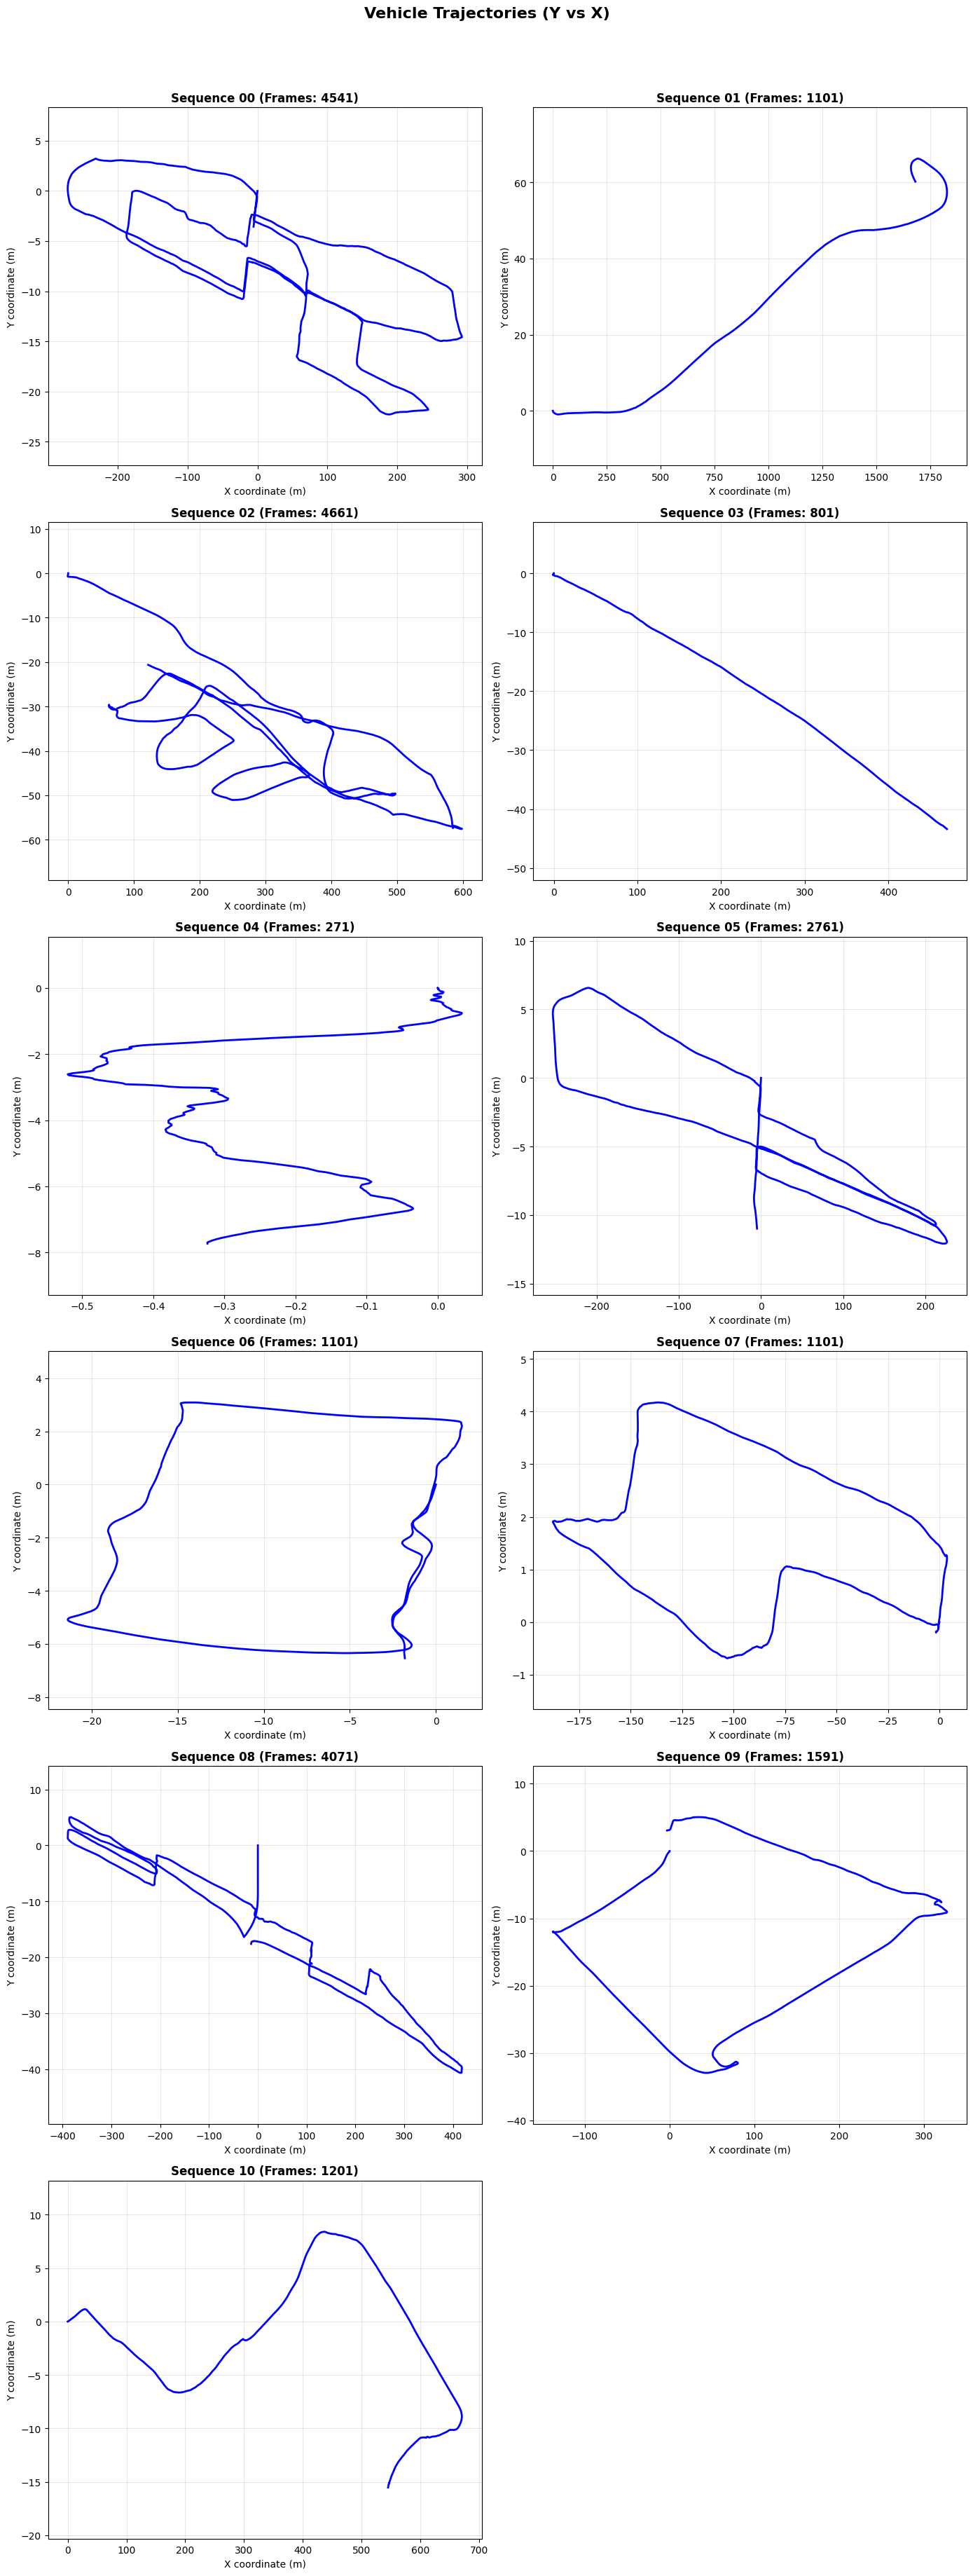

In [ ]:
# Использование функции
plot_all_poses(all_seq, cols=2, fig_width=14, fig_height_per_row=6, y_scale=2.0)

### raw

In [ ]:
l_car = 2.71
p = 3.674

In [ ]:
# Инициализация загрузчика
loader = KittiOxtsLoader(
    base_path=base_path,  # путь к вашим данным
    date='2011_09_30',
    drive='0020'
)
# Получение данных
print(f"Загружено кадров: {len(loader)}")

# Получить данные для конкретного кадра
idx = 0
packet = loader.get_oxts_packet(idx)  # Сырые OXTS данные
timestamp = loader.get_timestamp(idx) # Временная метка

print(f"Широта: {packet.lat}")
print(f"Долгота: {packet.lon}")
print(f"Высота: {packet.alt}")
print(f"Позиция: {loader.get_position(idx)}")

Загружено кадров: 1104
Широта: 49.05349304789598
Долгота: 8.39721998765449
Высота: 113.11204528807
Позиция: [0. 0. 0.]


In [ ]:
def extract_vehicle_state(loader, idx, l_car, p):
    """
    Извлекает вектор состояния X = [xk, yk, θk, vk, φk] из OXTS данных.

    Args:
        loader: KittiOxtsLoader instance
        idx: индекс кадра
        l_car: колесная база автомобиля в метрах
        p: расстояние от начала машины до задних колёс
    Returns:
        dict: вектор состояния и дополнительные параметры
    """
    # Получаем данные
    packet = loader.get_oxts_packet(idx)
    pose = loader.get_pose(idx)

    # Основной вектор состояния
    xk = pose[0, 3]    # x координата (восток)
    yk = pose[1, 3]    # y координата (север)
    θk = packet.yaw    # курс (heading) в радианах
    vk = packet.vf     # линейная скорость вперед (м/с)

    xk_1 = loader.get_pose(idx + 1)[0, 3]
    yk_1 = loader.get_pose(idx + 1)[1, 3]
    # ВЫЧИСЛЕНИЕ УГЛА ПОВОРОТА РУЛЯ φk
    dx = abs(xk_1 - xk)
    dy = abs(yk_1 - yk)
    #dx = (xk_1 - xk)
    #dy = (yk_1 - yk)
    dx2 = abs(xk_1**2 - xk**2)
    dy2 = abs(yk_1**2 - yk**2)
    φk = np.arctan((2 * dx * l_car) / (dy**2 + 2 * dy * p + dx**2)) #- np.pi / 2
    """
    if abs(vk) > 0.5:  # Избегаем деления на ноль и малых скоростей
        # φk = arctan((wheelbase * angular_velocity) / linear_velocity)
        φk = np.arctan2(wheelbase * packet.wz, vk)
    else:
        φk = 0.0  # При малой скорости угол поворота считается нулевым
    """

    # Ограничиваем угол поворота разумными пределами (±40°)
    #max_steering_angle = np.radians(40)
    #φk = np.clip(φk, -max_steering_angle, max_steering_angle)

    state_vector = {
        'X': np.array([xk, yk, θk, vk, φk]),
        'timestamp': loader.get_timestamp(idx),
        'angular_velocity': packet.wz
        #'steering_angle_deg': np.degrees(φk)
    }

    return state_vector

Форма массива состояний: (1103, 5)


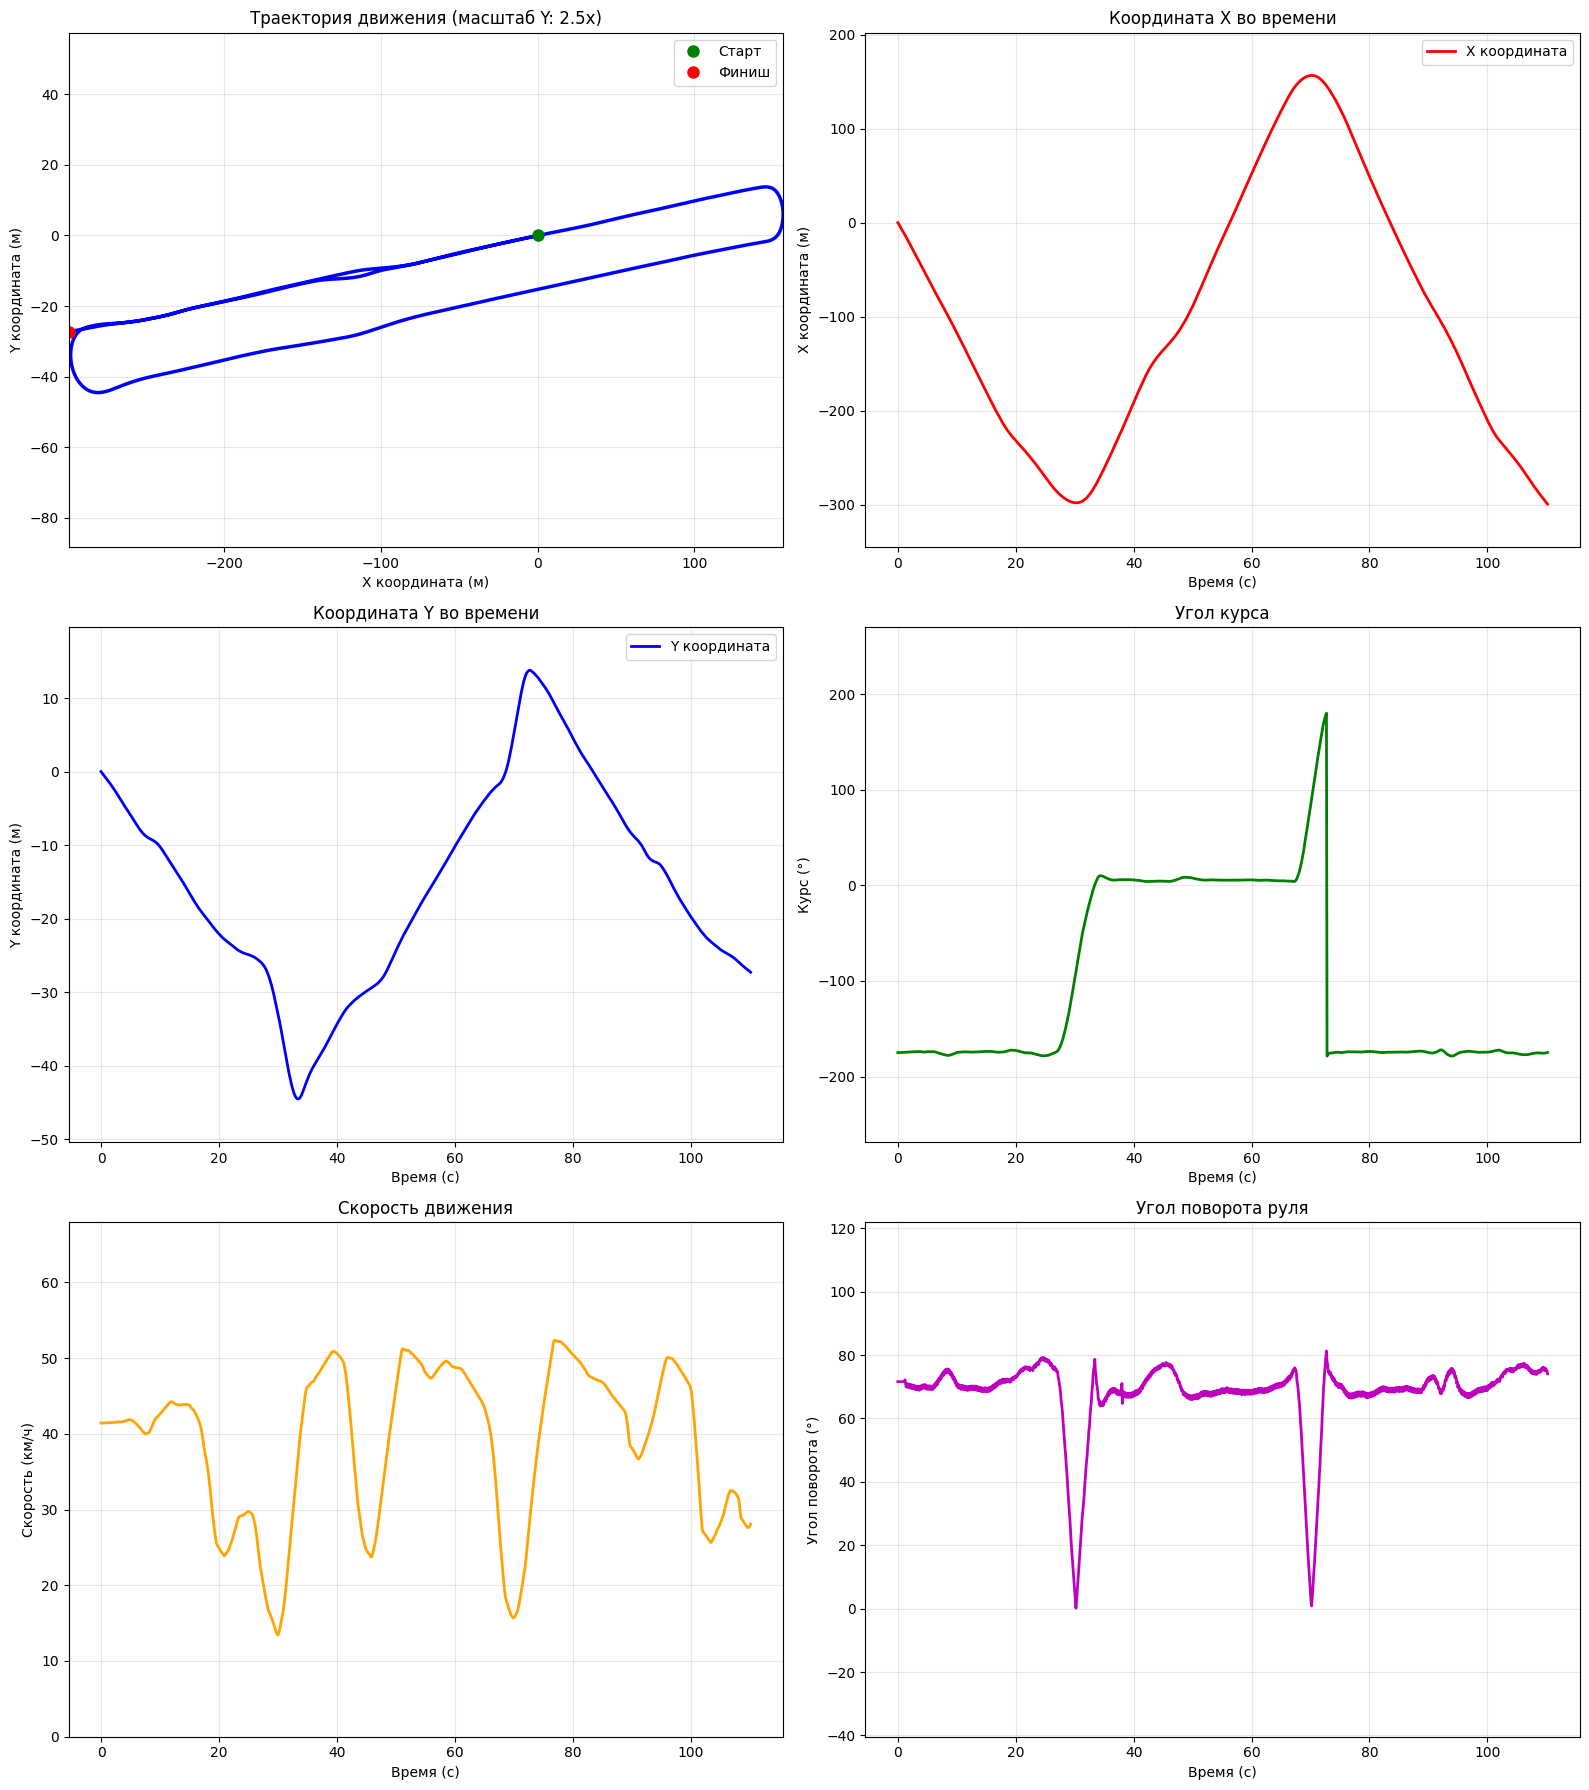

In [ ]:
# Извлечение всех состояний
all_states = []
for i in range(len(loader)-1):
    state = extract_vehicle_state(loader, i, l_car, p)
    all_states.append(state)

# Преобразование в numpy array для анализа
X_state_true = np.array([s['X'] for s in all_states])
print(f"Форма массива состояний: {X_state_true.shape}")



custom_scales_y = {'trajectory': 2.5, 'heading': 1.5, 'speed': 1.8, 'steering': 2.0, 'coordinates': 1.2}
plot_vehicle_states_custom(X_state_true, custom_scales_y)

In [ ]:
# Инициализация загрузчика
loader2 = KittiOxtsLoader(
    base_path=base_path,  # путь к вашим данным
    date='2011_09_26',
    drive='0117'
)
# Получение данных
print(f"Загружено кадров: {len(loader2)}")

# Получить данные для конкретного кадра
idx = 0
packet = loader2.get_oxts_packet(idx)  # Сырые OXTS данные
timestamp = loader2.get_timestamp(idx) # Временная метка

print(f"Широта: {packet.lat}")
print(f"Долгота: {packet.lon}")
print(f"Высота: {packet.alt}")
print(f"Позиция: {loader2.get_position(idx)}")

Загружено кадров: 660
Широта: 49.011647132256
Долгота: 8.411831900761
Высота: 117.50665283203
Позиция: [0. 0. 0.]


## Модель

In [ ]:
X_state_true[0, -1]

np.float64(0.06143512105051385)

In [ ]:
def simulate_trajectory_from_controls(controls_array, l_car, dt=0.1):
    """
    Моделирует траекторию vehicle по управляющим воздействиям (скорость и угол поворота)

    Parameters:
    -----------
    controls_array : numpy.ndarray shape (n, 5)
        Массив управляющих воздействий. Предполагается, что последние два столбца:
        [..., v, phi] где:
        v - линейная скорость (м/с)
        phi - угол поворота руля (радианы)
    l_car : float
        Колесная база vehicle в метрах
    dt : float
        Временной шаг между измерениями (секунды)

    Returns:
    --------
    trajectory : numpy.ndarray shape (n, 3)
        Массив траектории: [x, y, theta] для каждого временного шага
    """

    n = controls_array.shape[0]
    trajectory = np.zeros((n, 5))

    # Начальные условия (предполагаем начало в точке (0, 0, 0))
    x, y, theta = 0.0, 0.0, 0.0
    trajectory[0] = [x, y, theta,  controls_array[0, 3], controls_array[0, 4]]

    for k in range(n - 1):
        # Извлекаем скорость и угол поворота для текущего шага
        v_k = controls_array[k, 3]  # предпоследний столбец - скорость
        phi_k = controls_array[k, 4]  # последний столбец - угол поворота

        # Применяем уравнения движения
        x_next = np.cos(theta) * np.cos(phi_k) * v_k * dt + x
        y_next = np.sin(theta) * np.cos(phi_k) * v_k * dt + y
        theta_next = (np.sin(phi_k) * v_k * dt) / l_car + theta

        # Нормализуем угол theta в диапазон [-pi, pi]
        #theta_next = np.arctan2(np.sin(theta_next), np.cos(theta_next))

        # Сохраняем следующее состояние
        trajectory[k + 1] = [x_next, y_next, theta_next, v_k, phi_k]

        # Обновляем текущее состояние для следующей итерации
        x, y, theta = x_next, y_next, theta_next

    return trajectory


Размерность входных данных: (1103, 5)
Размерность выходной траектории: (1103, 5)
Начальная точка: [ 0.          0.          0.         11.5027826  -0.32069949]
Конечная точка: [  12.72213627  -13.11185151 -153.78301209    7.7501963    -0.25937636]


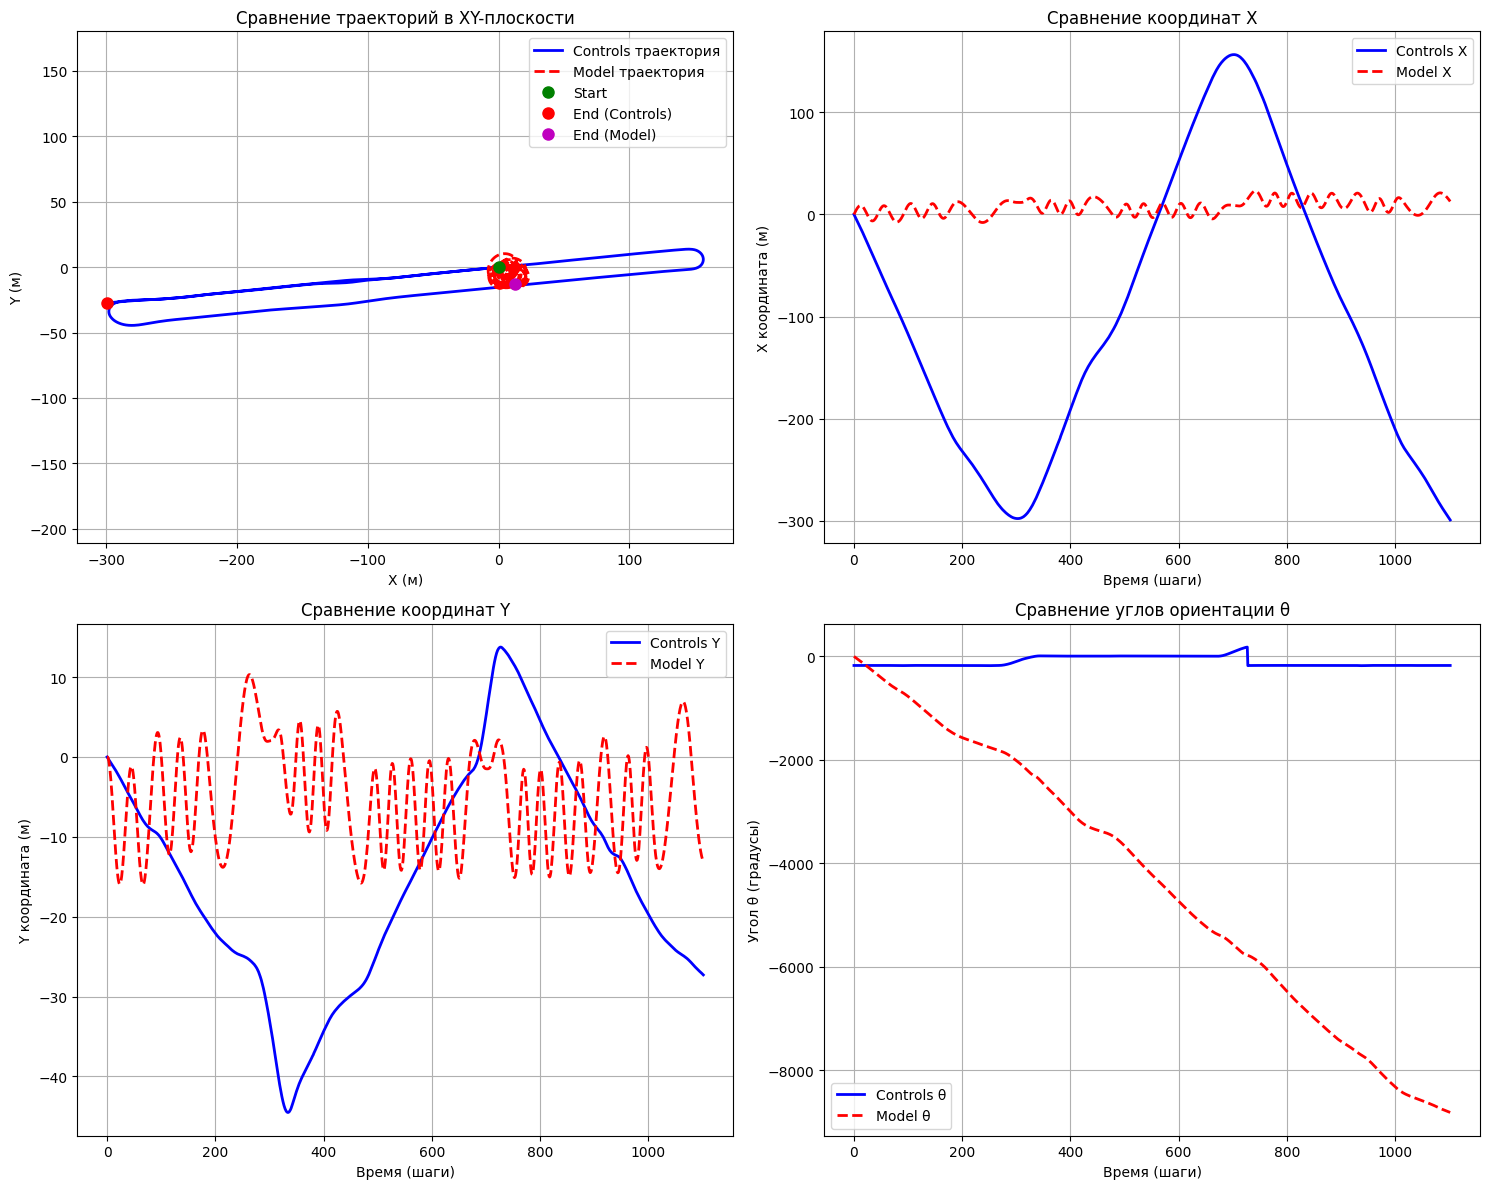

МЕТРИКИ СРАВНЕНИЯ ТРАЕКТОРИЙ
RMSE по X: 174.5762 м
RMSE по Y: 19.3789 м
Общий RMSE: 175.6485 м
Максимальная ошибка по X: 311.9924 м
Максимальная ошибка по Y: 45.3860 м
Конечная позиция Controls: (-299.27, -27.29) м
Конечная позиция Model:    (12.72, -13.11) м
Расстояние между конечными точками: 312.3146 м


In [ ]:
# Моделируем траекторию
X_state_model = simulate_trajectory_from_controls(X_state_true, l_car=l_car, dt=0.1)

print(f"Размерность входных данных: {X_state_true.shape}")
print(f"Размерность выходной траектории: {X_state_model.shape}")
print(f"Начальная точка: {X_state_model[0]}")
print(f"Конечная точка: {X_state_model[-1]}")

# Визуализируем результаты
plot_trajectory_comparison(X_state_true, X_state_model)

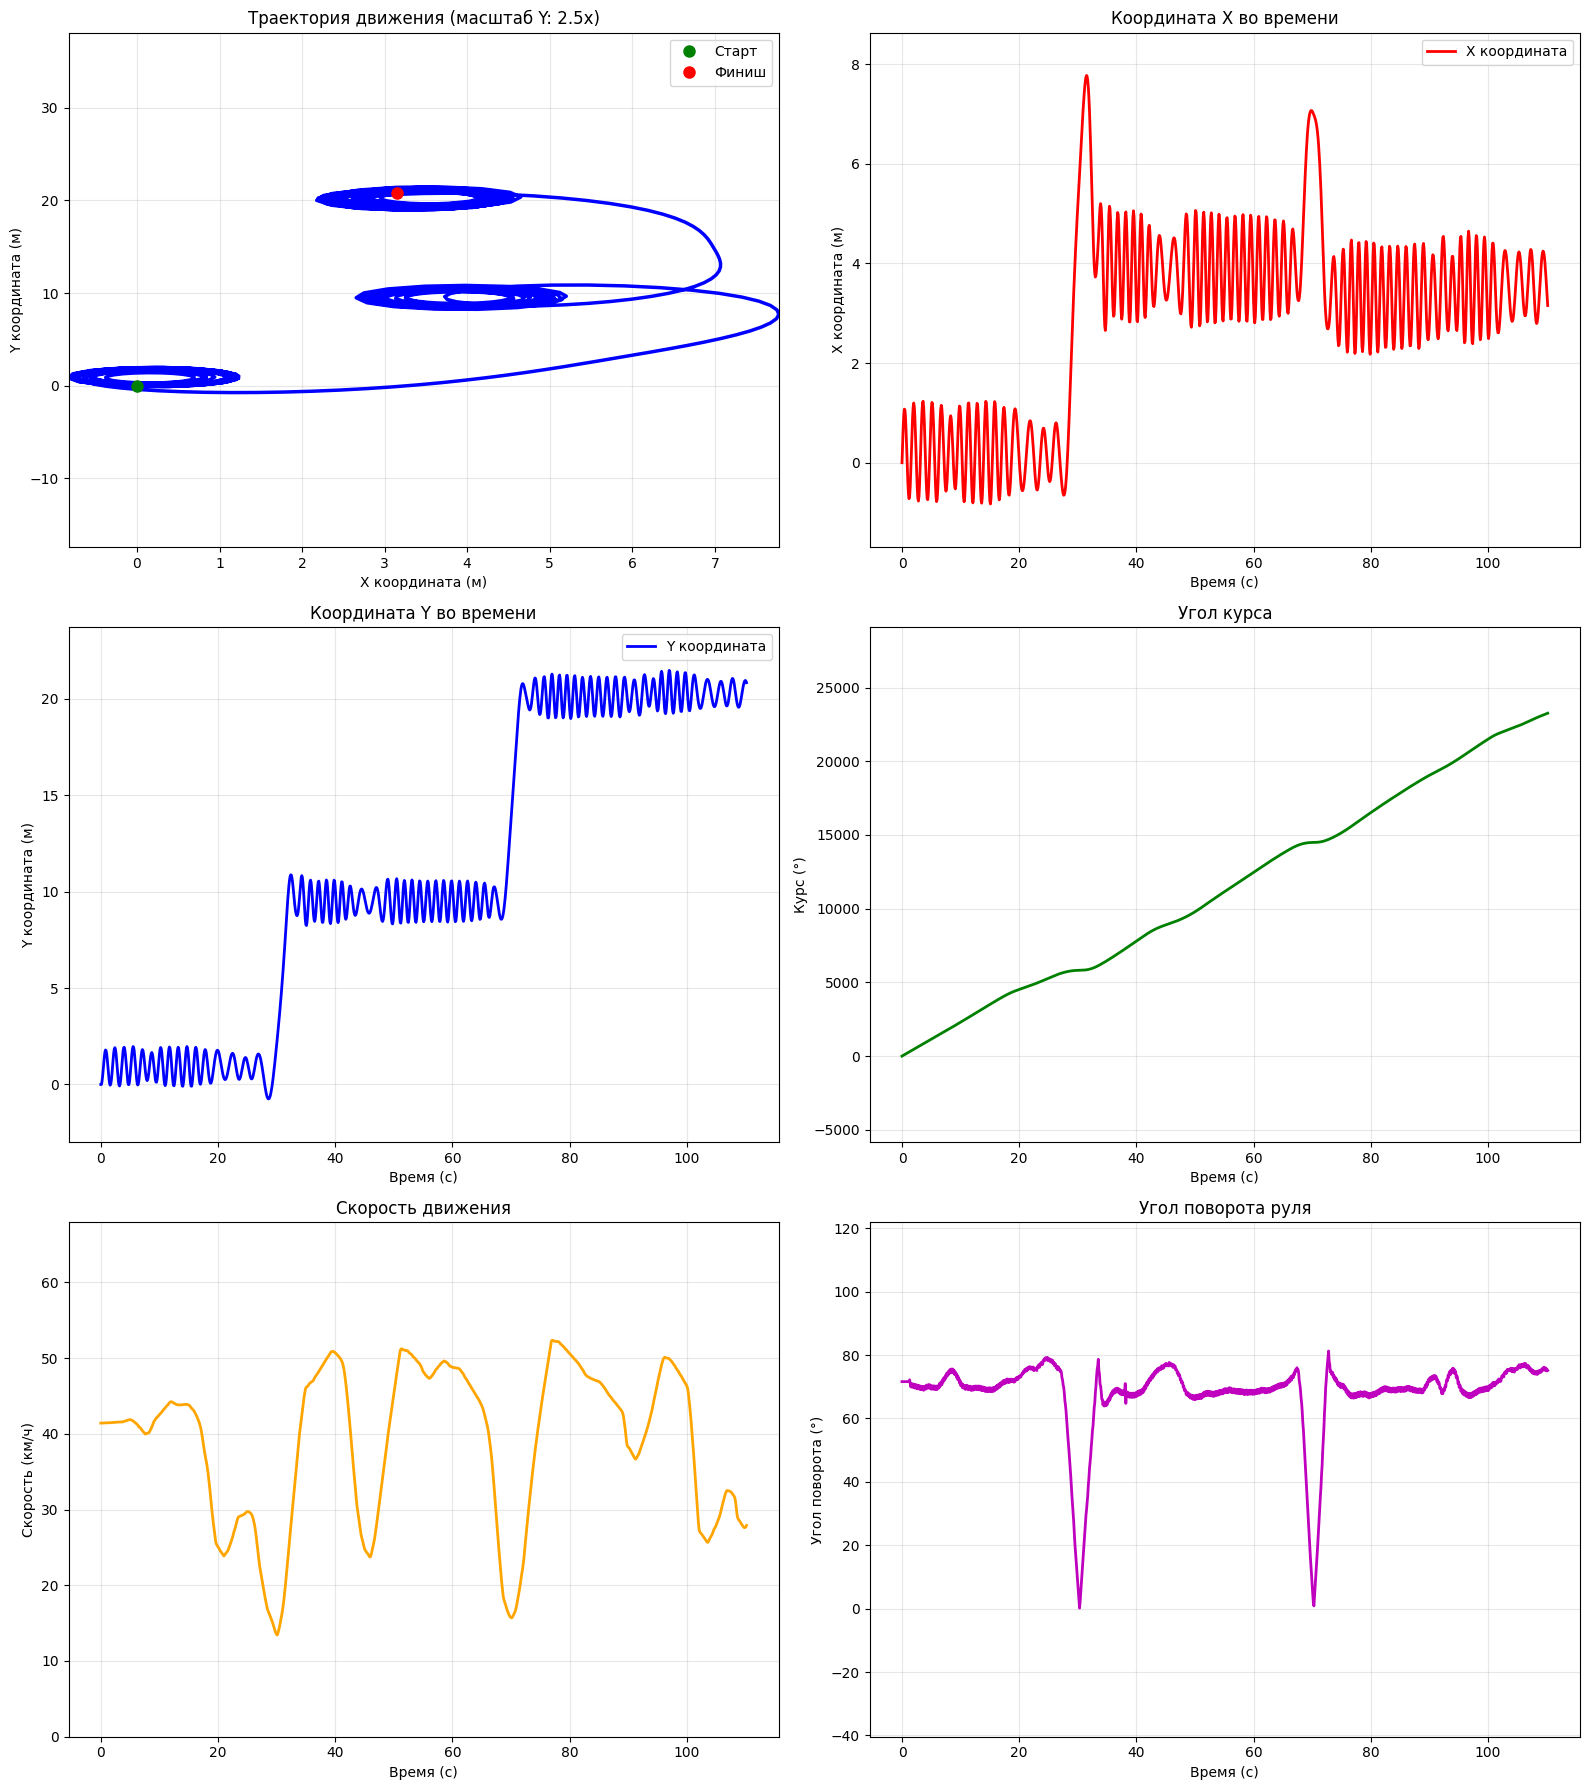

In [ ]:
plot_vehicle_states_custom(X_state_model, custom_scales_y)

In [ ]:
def state_GPS(state, l_off, alpha, dt=0.1):
    n = state.shape[0]
    trajectory = np.zeros((n, 3))

    # Начальные условия (предполагаем начало в точке (0, 0, 0))
    x, y, theta = state[0, 0], state[0, 1], state[0, 2]
    trajectory[0] = [x, y, theta]

    for k in range(n - 1):
        x_next = x - l_off * np.cos(theta - alpha)
        y_next = y - l_off * np.sin(theta - alpha)
        theta_next = theta

        # Нормализуем угол theta в диапазон [-pi, pi]
        #theta_next = np.arctan(np.sin(theta_next) / np.cos(theta_next))

        # Сохраняем следующее состояние
        trajectory[k + 1] = [x_next, y_next, theta_next]

        # Обновляем текущее состояние для следующей итерации
        x, y, theta = x_next, y_next, theta_next

    return trajectory

In [ ]:
l_off = 0.323
alpha = 0.154

Размерность входных данных: (1103, 3)
Размерность выходной траектории: (1103, 3)
Начальная точка: [ 0.          0.         -3.05417498]
Конечная точка: [355.15730042 -23.68220582  -3.05417498]


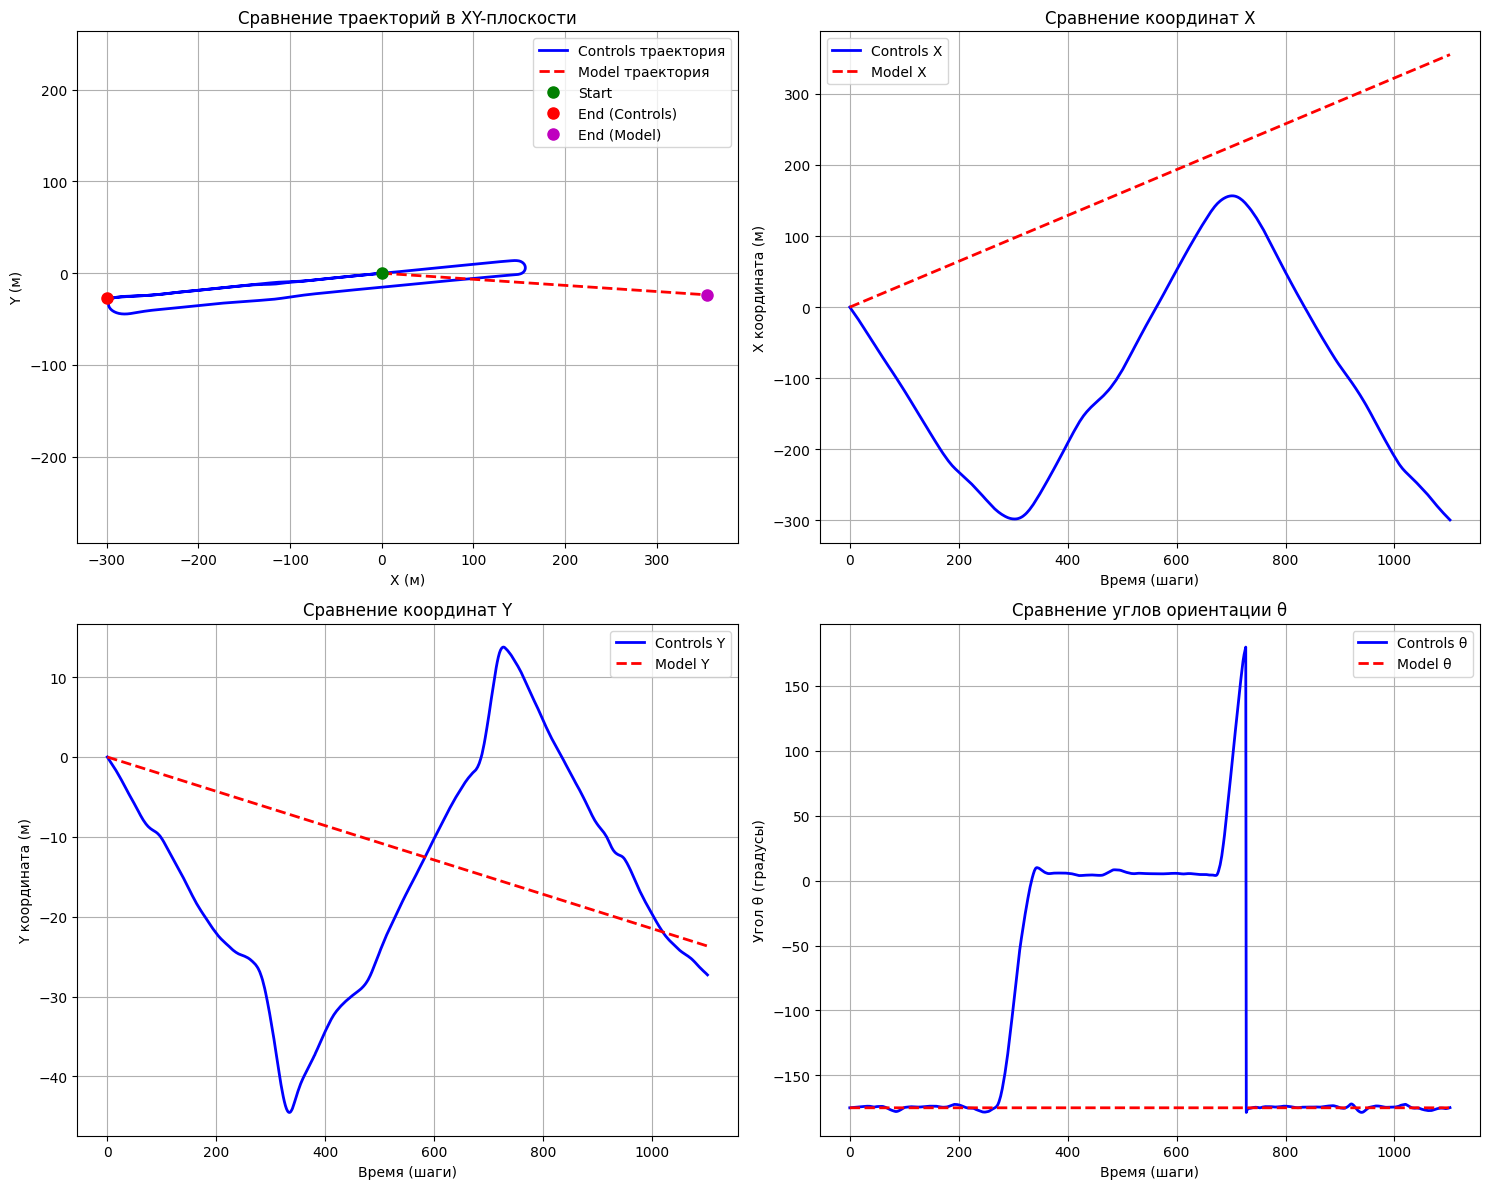

МЕТРИКИ СРАВНЕНИЯ ТРАЕКТОРИЙ
RMSE по X: 319.2210 м
RMSE по Y: 17.1652 м
Общий RMSE: 319.6822 м
Максимальная ошибка по X: 654.4276 м
Максимальная ошибка по Y: 37.3458 м
Конечная позиция Controls: (-299.27, -27.29) м
Конечная позиция Model:    (355.16, -23.68) м
Расстояние между конечными точками: 654.4375 м


In [ ]:
# Моделируем траекторию
X_GPS_model = state_GPS(X_state_model, l_off=l_off, alpha=alpha, dt=0.1)

print(f"Размерность входных данных: {X_state_model.shape}")
print(f"Размерность выходной траектории: {X_GPS_model.shape}")
print(f"Начальная точка: {X_GPS_model[0]}")
print(f"Конечная точка: {X_GPS_model[-1]}")

# Визуализируем результаты
plot_trajectory_comparison(X_state_true, X_GPS_model)

# Парсим заново


## функции

In [ ]:
#2 способ
def step2_get_ABcords(state_x, mx = 3.724, my = -0.32):
  n = state_x.shape[0]
  cords_AB = np.zeros((n, 3))
  for i in range(n):
    teta = state_x[i, 2]
    #teta = np.arctan2(np.sin(teta), np.cos(teta))

    x_gps = mx * np.cos(teta) - my * np.sin(teta) + state_x[i, 0]
    y_gps = mx * np.sin(teta) + my * np.cos(teta) + state_x[i, 1]
    cords_AB[i] = [x_gps, y_gps, teta]

  return cords_AB

def step2_get_Bcar(cords_A, state_x, mx = 3.724, my = -0.32):
  n = cords_A.shape[0]
  cords_B = np.zeros((n, 2))
  for i in range(1, n):
    teta = cords_A[i-1, 2]
    x_g = state_x[i-1, 0]
    y_g = state_x[i-1, 1]
    x_gps = cords_A[i, 0]
    y_gps = cords_A[i, 1]
    # переводим координаты В в систему car_A
    x_car = (x_gps - x_g)* np.cos(teta) + (y_gps - y_g)* np.sin(teta)
    y_car = - (x_gps - x_g) * np.sin(teta) + (y_gps - y_g) * np.cos(teta)
    # считаем дельты координат
    cords_B[i-1] = [x_car - mx, y_car - my]

  return cords_B

def step3_get_phi5(cords_B, l_car, p):
  n = cords_B.shape[0]
  arr_phi = np.zeros(n)
  for i in range(n-1):
    dx_new = cords_B[i, 0]
    dy_new = cords_B[i, 1]

    phi = np.arctan2((2 * dy_new * l_car), (dy_new**2 + 2 * dx_new * p + dx_new**2))
    arr_phi[i] = phi
  return arr_phi

In [ ]:
def simulate_trajectory_from_controls(controls_array, l_car, dt=0.1):
    """
    Моделирует траекторию vehicle по управляющим воздействиям (скорость и угол поворота)

    Parameters:
    -----------
    controls_array : numpy.ndarray shape (n, 5)
        Массив управляющих воздействий. Предполагается, что последние два столбца:
        [..., v, phi] где:
        v - линейная скорость (м/с)
        phi - угол поворота руля (радианы)
    l_car : float
        Колесная база vehicle в метрах
    dt : float
        Временной шаг между измерениями (секунды)

    Returns:
    --------
    trajectory : numpy.ndarray shape (n, 3)
        Массив траектории: [x, y, theta] для каждого временного шага
    """

    n = controls_array.shape[0]
    trajectory = np.zeros((n, 5))

    # Начальные условия (предполагаем начало в точке (0, 0, 0))
    x, y, theta = 0.0, 0.0, 0.0
    trajectory[0] = [x, y, theta,  controls_array[0, 3], controls_array[0, 4]]

    for k in range(n - 1):
        # Извлекаем скорость и угол поворота для текущего шага
        v_k = controls_array[k, 3]  # предпоследний столбец - скорость
        phi_k = controls_array[k, 4]  # последний столбец - угол поворота

        # Применяем уравнения движения
        x_next = np.cos(theta) * np.cos(phi_k) * v_k * dt + x
        y_next = np.sin(theta) * np.cos(phi_k) * v_k * dt + y
        theta_next = (np.sin(phi_k) * v_k * dt) / l_car + theta

        # Нормализуем угол theta в диапазон [-pi, pi]
        theta_next = np.arctan2(np.sin(theta_next), np.cos(theta_next))

        # Сохраняем следующее состояние
        trajectory[k + 1] = [x_next, y_next, theta_next, v_k, phi_k]

        # Обновляем текущее состояние для следующей итерации
        x, y, theta = x_next, y_next, theta_next

    return trajectory

In [ ]:
class KittiOxtsParser:
    """
    Парсер и калибратор GPS/IMU данных KITTI
    """

    def __init__(self, base_path: str, date: str = '2011_09_30', drive: str = '0020'):
        """
        Инициализация парсера

        Args:
            base_path: Базовый путь к датасету KITTI
            date: Дата записи (формат: YYYY_MM_DD)
            drive: Номер поездки
        """
        self.base_path = Path(base_path)
        self.date = date
        self.drive = drive

        # Структура папок (должна существовать)
        self.sequence_dir = self.base_path / f"{date}_drive_{drive}_sync"
        self.oxts_dir = self.sequence_dir / "oxts"
        self.data_dir = self.oxts_dir / "data"
        self.timestamps_file = self.oxts_dir / "timestamps.txt"

        # Проверка структуры
        self._check_structure()

        # Инициализация
        self.scale = None
        self.first_pose_inv = None
        self.oxts_data = None
        self.poses = None

    def _check_structure(self):
        """Проверка структуры папок и файлов"""
        required_dirs = [self.sequence_dir, self.oxts_dir, self.data_dir]
        required_files = [self.timestamps_file]

        for dir_path in required_dirs:
            if not dir_path.exists():
                raise FileNotFoundError(f"Директория не найдена: {dir_path}")

        for file_path in required_files:
            if not file_path.exists():
                raise FileNotFoundError(f"Файл не найден: {file_path}")

        # Проверка наличия файлов с данными
        data_files = list(self.data_dir.glob("*.txt"))
        if len(data_files) == 0:
            raise FileNotFoundError(f"Нет файлов с данными в {self.data_dir}")

        print(f"Структура OK: найдено {len(data_files)} файлов с данными")

    @staticmethod
    def lat_to_scale(lat_deg: float) -> float:
        """
        Вычисление масштаба Меркатора из широты

        Args:
            lat_deg: Широта в градусах

        Returns:
            Масштабный коэффициент
        """
        return math.cos(lat_deg * math.pi / 180.0)

    @staticmethod
    def latlon_to_mercator(lat_deg: float, lon_deg: float, scale: float) -> Tuple[float, float]:
        """
        Преобразование географических координат в координаты Меркатора

        Args:
            lat_deg: Широта в градусах
            lon_deg: Долгота в градусах
            scale: Масштабный коэффициент

        Returns:
            Координаты (x, y) в метрах
        """
        earth_radius = 6378137.0  # радиус Земли в метрах

        # Преобразование в метры
        mx = scale * lon_deg * math.pi * earth_radius / 180.0
        my = scale * earth_radius * math.log(
            math.tan((90.0 + lat_deg) * math.pi / 360.0)
        )

        return mx, my

    @staticmethod
    def wrap_to_pi(angle: float) -> float:
        """
        Нормализация угла в диапазон [-π, π]

        Args:
            angle: Угол в радианах

        Returns:
            Нормализованный угол
        """
        # Оборачиваем в [0, 2π]
        angle = angle % (2 * math.pi)

        # Оборачиваем в [-π, π]
        if angle > math.pi:
            angle -= 2 * math.pi

        return angle

    def load_oxts_data(self, frames: Optional[List[int]] = None) -> List[np.ndarray]:
        """
        Загрузка RAW GPS/IMU данных

        Args:
            frames: Список кадров для загрузки (None = все кадры)

        Returns:
            Список массивов с 30 параметрами для каждого кадра
        """
        if frames is None:
            # Загружаем все кадры
            num_frames = len(list(self.data_dir.glob("*.txt")))
            frames = list(range(num_frames))

        oxts_list = []

        for frame_idx in frames:
            file_name = self.data_dir / f"{frame_idx:010d}.txt"

            try:
                # Загружаем 30 значений из файла
                data = np.loadtxt(file_name)
                if data.ndim == 0:  # Если только одно значение
                    data = np.array([data])
                oxts_list.append(data)
            except Exception as e:
                print(f"Ошибка при загрузке {file_name}: {e}")
                oxts_list.append(np.array([]))

        self.oxts_data = oxts_list
        return oxts_list

    def convert_oxts_to_pose(self) -> List[np.ndarray]:
        """
        Преобразование OXTS измерений в метрические позы

        Returns:
            Список 4x4 матриц преобразования
        """
        if self.oxts_data is None:
            self.load_oxts_data()

        # Вычисляем масштаб из первой широты
        first_lat = self.oxts_data[0][0]
        self.scale = self.lat_to_scale(first_lat)

        poses = []
        first_pose_inv = None

        for i, oxts in enumerate(self.oxts_data):
            # Если нет данных - пропускаем
            if len(oxts) == 0:
                poses.append(np.array([]))
                continue

            # Извлекаем параметры
            lat, lon, alt = oxts[0], oxts[1], oxts[2]
            roll, pitch, yaw = oxts[3], oxts[4], oxts[5]

            # Вектор перевода (в координаты Меркатора)
            mx, my = self.latlon_to_mercator(lat, lon, self.scale)
            t = np.array([[mx], [my], [alt]])

            # Матрица поворота (OXTS RT3000 manual, стр. 71)
            Rx = np.array([
                [1, 0, 0],
                [0, math.cos(roll), -math.sin(roll)],
                [0, math.sin(roll), math.cos(roll)]
            ])  # base => nav

            Ry = np.array([
                [math.cos(pitch), 0, math.sin(pitch)],
                [0, 1, 0],
                [-math.sin(pitch), 0, math.cos(pitch)]
            ])  # base => nav

            Rz = np.array([
                [math.cos(yaw), -math.sin(yaw), 0],
                [math.sin(yaw), math.cos(yaw), 0],
                [0, 0, 1]
            ])  # base => nav

            R = Rz @ Ry @ Rx

            # Создаем матрицу преобразования 4x4
            T = np.eye(4)
            T[:3, :3] = R
            T[:3, 3] = t.flatten()

            # Нормализуем (первая поза = начало координат)
            if first_pose_inv is None:
                first_pose_inv = np.linalg.inv(T)
                self.first_pose_inv = first_pose_inv

            # Преобразуем в координаты первой позы
            pose = first_pose_inv @ T
            poses.append(pose)

        self.poses = poses
        return poses

    def extract_vehicle_state(self) -> Dict[str, np.ndarray]:
        """
        Извлечение состояния транспортного средства: x, y, yaw, vf

        Returns:
            Словарь с массивами параметров
        """
        if self.poses is None:
            self.convert_oxts_to_pose()

        n = len(self.poses)
        x_coords = np.zeros(n)
        y_coords = np.zeros(n)
        yaw_angles = np.zeros(n)
        vf_speeds = np.zeros(n)

        for i in range(n):
            pose = self.poses[i]
            oxts = self.oxts_data[i]

            if len(pose) == 0 or len(oxts) == 0:
                x_coords[i] = np.nan
                y_coords[i] = np.nan
                yaw_angles[i] = np.nan
                vf_speeds[i] = np.nan
                continue

            # x, y из матрицы преобразования (трансляционная часть)
            x_coords[i] = pose[0, 3]
            y_coords[i] = pose[1, 3]

            # yaw (heading) из матрицы поворота
            R = pose[:3, :3]
            yaw_angles[i] = math.atan2(R[1, 0], R[0, 0])

            # vf (forward velocity) - 9-й элемент в OXTS данных (индекс 8)
            vf_speeds[i] = oxts[8] if len(oxts) > 8 else 0.0

        # Удаляем NaN значения
        valid_mask = ~np.isnan(x_coords)
        x_coords = x_coords[valid_mask]
        y_coords = y_coords[valid_mask]
        yaw_angles = yaw_angles[valid_mask]
        vf_speeds = vf_speeds[valid_mask]

        # 🚀 Ключевое исправление: убираем скачки в yaw с помощью np.unwrap
        yaw_angles = np.unwrap(yaw_angles)

        return {
            'x': x_coords,
            'y': y_coords,
            'yaw': yaw_angles,
            'vf': vf_speeds,
            'num_frames': n,
            'valid_frames': len(x_coords)
        }

    def load_timestamps(self) -> List[float]:
        """
        Загрузка временных меток

        Returns:
            Список временных меток в секундах
        """
        timestamps = []

        with open(self.timestamps_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                # Парсим строку формата: 2011-09-30 13:03:41.123456789
                try:
                    # Упрощенный парсинг (можно улучшить)
                    parts = line.split()
                    time_str = parts[1]  # Время

                    # Преобразуем в секунды
                    h, m, s = time_str.split(':')
                    seconds = float(h) * 3600 + float(m) * 60 + float(s)
                    timestamps.append(seconds)
                except:
                    timestamps.append(0.0)

        return timestamps

    def get_trajectory(self) -> np.ndarray:
        """
        Получение траектории (x, y, yaw)

        Returns:
            Массив формы (n, 3) с координатами и углом
        """
        state = self.extract_vehicle_state()
        return np.column_stack([state['x'], state['y'], state['yaw']])


In [ ]:
def plot_comparison(controls_array, trajectory_array, title="Сравнение траекторий"):
    # Создаем 4 отдельных графика
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    time = np.arange(controls_array.shape[0])

    # График 1: Траектории в XY-плоскости
    ax1.plot(controls_array[:, 0], controls_array[:, 1], 'b-', linewidth=2, label='GPS траектория')
    ax1.plot(trajectory_array[:, 0], trajectory_array[:, 1], 'r--', linewidth=2, label='Center траектория')
    ax1.plot(controls_array[0, 0], controls_array[0, 1], 'go', markersize=8, label='Start_G')
    ax1.plot(trajectory_array[0, 0], trajectory_array[0, 1], 'bo', markersize=8, label='Start_A')

    ax1.plot(controls_array[-1, 0], controls_array[-1, 1], 'ro', markersize=8, label='End (G)')
    ax1.plot(trajectory_array[-1, 0], trajectory_array[-1, 1], 'mo', markersize=8, label='End (A)')
    ax1.set_xlabel('X (м)')
    ax1.set_ylabel('Y (м)')
    ax1.set_title('Сравнение траекторий в XY-плоскости')
    ax1.legend()
    ax1.grid(True)
    ax1.axis('equal')

In [ ]:
# Пример использования
def main(base_path):
    # Укажите правильный путь к вашему датасету KITTI
    BASE_PATH = base_path  # ИЗМЕНИТЕ ЭТОТ ПУТЬ!

    # Создаем парсер
    parser = KittiOxtsParser(
        base_path=BASE_PATH,
        date='2011_09_30',
        drive='0020'
    )

    # Загружаем и преобразуем данные
    print("Загрузка GPS/IMU данных...")
    oxts_data = parser.load_oxts_data()
    print(f"Загружено {len(oxts_data)} кадров")

    print("Преобразование в позы...")
    poses = parser.convert_oxts_to_pose()

    print("Извлечение состояния...")
    state = parser.extract_vehicle_state()

    # Вывод статистики
    print("\n=== Статистика ===")
    print(f"Всего кадров: {state['num_frames']}")
    print(f"Валидных кадров: {state['valid_frames']}")
    print(f"Диапазон X: [{state['x'].min():.2f}, {state['x'].max():.2f}] м")
    print(f"Диапазон Y: [{state['y'].min():.2f}, {state['y'].max():.2f}] м")
    print(f"Диапазон Yaw: [{state['yaw'].min():.2f}, {state['yaw'].max():.2f}] рад")
    print(f"Диапазон Vf: [{state['vf'].min():.2f}, {state['vf'].max():.2f}] м/с")

    # Получаем траекторию
    trajectory = parser.get_trajectory()
    print(f"\nТраектория shape: {trajectory.shape}")

    return parser, state, trajectory


# Визуализация
def plot_trajectory(state: Dict[str, np.ndarray], frame_rate: float = 10.0):
    """
    Визуализация траектории

    Args:
        state: Словарь с данными состояния
        frame_rate: Частота кадров (Гц) для расчета времени
    """
    # Рассчитываем временную ось
    num_frames = len(state['x'])
    time_axis = np.arange(num_frames) / frame_rate  # Время в секундах

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Траектория x-y с точками старта и финиша
    axes[0, 0].plot(state['x'], state['y'], 'b-', linewidth=1.5, alpha=0.8)
    # Зеленая точка старта
    axes[0, 0].plot(state['x'][0], state['y'][0], 'go',
                   markersize=12, label='Старт', zorder=5, markeredgewidth=2)
    # Красная точка финиша
    axes[0, 0].plot(state['x'][-1], state['y'][-1], 'ro',
                   markersize=12, label='Финиш', zorder=5, markeredgewidth=2)
    axes[0, 0].set_title('Траектория движения', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('X (м)', fontsize=10)
    axes[0, 0].set_ylabel('Y (м)', fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axis('equal')
    axes[0, 0].legend(fontsize=10, loc='best')

    # 2. Yaw во времени (в градусах)
    yaw_deg = np.degrees(state['yaw'])  # Конвертация в градусы
    axes[0, 1].plot(time_axis, yaw_deg, 'g-', linewidth=1.5)
    axes[0, 1].set_title('Угол курса (Yaw)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Время (с)', fontsize=10)
    axes[0, 1].set_ylabel('Yaw (°)', fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim(0, time_axis[-1])

    # 3. Скорость во времени
    axes[1, 0].plot(time_axis, state['vf'], 'r-', linewidth=1.5)
    axes[1, 0].set_title('Скорость вперед (Vf)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Время (с)', fontsize=10)
    axes[1, 0].set_ylabel('Vf (м/с)', fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, time_axis[-1])

    # Добавляем информационную панель под графиками
    plt.figtext(0.5, 0.01,
                f"Частота кадров: {frame_rate} Гц | "
                f"Длительность: {time_axis[-1]:.1f} с | "
                f"Кадров: {num_frames} | "
                f"ΔX: {state['x'][-1] - state['x'][0]:.1f} м | "
                f"ΔY: {state['y'][-1] - state['y'][0]:.1f} м | "
                f"Vf ср.: {np.mean(state['vf']):.2f} ± {np.std(state['vf']):.2f} м/с",
                ha="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.5))

    plt.suptitle(f'Анализ траектории движения',
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])  # Оставляем место для текста снизу
    plt.show()

    # Дополнительный график: раздельные X(t) и Y(t) если нужно
    fig2, (ax_x, ax_y) = plt.subplots(1, 2, figsize=(12, 5))

    # X во времени
    ax_x.plot(time_axis, state['x'], 'b-', linewidth=2)
    ax_x.set_title('Координата X', fontsize=12, fontweight='bold')
    ax_x.set_xlabel('Время (с)', fontsize=10)
    ax_x.set_ylabel('X (м)', fontsize=10)
    ax_x.grid(True, alpha=0.3)
    ax_x.set_xlim(0, time_axis[-1])

    # Y во времени
    ax_y.plot(time_axis, state['y'], 'g-', linewidth=2)
    ax_y.set_title('Координата Y', fontsize=12, fontweight='bold')
    ax_y.set_xlabel('Время (с)', fontsize=10)
    ax_y.set_ylabel('Y (м)', fontsize=10)
    ax_y.grid(True, alpha=0.3)
    ax_y.set_xlim(0, time_axis[-1])

    plt.suptitle('Координаты во времени', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

In [ ]:
class KittiOxtsParser:
    """
    Парсер и калибратор GPS/IMU данных KITTI
    """

    def __init__(self, base_path: str, date: str = '2011_09_30', drive: str = '0020'):
        """
        Инициализация парсера

        Args:
            base_path: Базовый путь к датасету KITTI
            date: Дата записи (формат: YYYY_MM_DD)
            drive: Номер поездки
        """
        self.base_path = Path(base_path)
        self.date = date
        self.drive = drive

        # Структура папок (должна существовать)
        self.sequence_dir = self.base_path / f"{date}_drive_{drive}_sync"
        self.oxts_dir = self.sequence_dir / "oxts"
        self.data_dir = self.oxts_dir / "data"
        self.timestamps_file = self.oxts_dir / "timestamps.txt"

        # Проверка структуры
        self._check_structure()

        # Инициализация
        self.scale = None
        self.first_pose_inv = None
        self.oxts_data = None
        self.poses = None

    def _check_structure(self):
        """Проверка структуры папок и файлов"""
        required_dirs = [self.sequence_dir, self.oxts_dir, self.data_dir]
        required_files = [self.timestamps_file]

        for dir_path in required_dirs:
            if not dir_path.exists():
                raise FileNotFoundError(f"Директория не найдена: {dir_path}")

        for file_path in required_files:
            if not file_path.exists():
                raise FileNotFoundError(f"Файл не найден: {file_path}")

        # Проверка наличия файлов с данными
        data_files = list(self.data_dir.glob("*.txt"))
        if len(data_files) == 0:
            raise FileNotFoundError(f"Нет файлов с данными в {self.data_dir}")

        print(f"Структура OK: найдено {len(data_files)} файлов с данными")

    @staticmethod
    def lat_to_scale(lat_deg: float) -> float:
        """
        Вычисление масштаба Меркатора из широты

        Args:
            lat_deg: Широта в градусах

        Returns:
            Масштабный коэффициент
        """
        return math.cos(lat_deg * math.pi / 180.0)

    @staticmethod
    def latlon_to_mercator(lat_deg: float, lon_deg: float, scale: float) -> Tuple[float, float]:
        """
        Преобразование географических координат в координаты Меркатора

        Args:
            lat_deg: Широта в градусах
            lon_deg: Долгота в градусах
            scale: Масштабный коэффициент

        Returns:
            Координаты (x, y) в метрах
        """
        earth_radius = 6378137.0  # радиус Земли в метрах

        # Преобразование в метры
        mx = scale * lon_deg * math.pi * earth_radius / 180.0
        my = scale * earth_radius * math.log(
            math.tan((90.0 + lat_deg) * math.pi / 360.0)
        )

        return mx, my

    @staticmethod
    def wrap_to_pi(angle: float) -> float:
        """
        Нормализация угла в диапазон [-π, π]

        Args:
            angle: Угол в радианах

        Returns:
            Нормализованный угол
        """
        # Оборачиваем в [0, 2π]
        angle = angle % (2 * math.pi)

        # Оборачиваем в [-π, π]
        if angle > math.pi:
            angle -= 2 * math.pi

        return angle

    def load_oxts_data(self, frames: Optional[List[int]] = None) -> List[np.ndarray]:
        """
        Загрузка RAW GPS/IMU данных

        Args:
            frames: Список кадров для загрузки (None = все кадры)

        Returns:
            Список массивов с 30 параметрами для каждого кадра
        """
        if frames is None:
            # Загружаем все кадры
            num_frames = len(list(self.data_dir.glob("*.txt")))
            frames = list(range(num_frames))

        oxts_list = []

        for frame_idx in frames:
            file_name = self.data_dir / f"{frame_idx:010d}.txt"

            try:
                # Загружаем 30 значений из файла
                data = np.loadtxt(file_name)
                if data.ndim == 0:  # Если только одно значение
                    data = np.array([data])
                oxts_list.append(data)
            except Exception as e:
                print(f"Ошибка при загрузке {file_name}: {e}")
                oxts_list.append(np.array([]))

        self.oxts_data = oxts_list
        return oxts_list

    def convert_oxts_to_pose(self) -> List[np.ndarray]:
        """
        Преобразование OXTS измерений в метрические позы

        Returns:
            Список 4x4 матриц преобразования
        """
        if self.oxts_data is None:
            self.load_oxts_data()

        # Вычисляем масштаб из первой широты
        first_lat = self.oxts_data[0][0]
        self.scale = self.lat_to_scale(first_lat)

        poses = []
        first_pose_inv = None

        for i, oxts in enumerate(self.oxts_data):
            # Если нет данных - пропускаем
            if len(oxts) == 0:
                poses.append(np.array([]))
                continue

            # Извлекаем параметры
            lat, lon, alt = oxts[0], oxts[1], oxts[2]
            roll, pitch, yaw = oxts[3], oxts[4], oxts[5]

            # Вектор перевода (в координаты Меркатора)
            mx, my = self.latlon_to_mercator(lat, lon, self.scale)
            t = np.array([[mx], [my], [alt]])

            # Матрица поворота (OXTS RT3000 manual, стр. 71)
            Rx = np.array([
                [1, 0, 0],
                [0, math.cos(roll), -math.sin(roll)],
                [0, math.sin(roll), math.cos(roll)]
            ])  # base => nav

            Ry = np.array([
                [math.cos(pitch), 0, math.sin(pitch)],
                [0, 1, 0],
                [-math.sin(pitch), 0, math.cos(pitch)]
            ])  # base => nav

            Rz = np.array([
                [math.cos(yaw), -math.sin(yaw), 0],
                [math.sin(yaw), math.cos(yaw), 0],
                [0, 0, 1]
            ])  # base => nav

            R = Rz @ Ry @ Rx

            # Создаем матрицу преобразования 4x4
            T = np.eye(4)
            T[:3, :3] = R
            T[:3, 3] = t.flatten()

            # Нормализуем (первая поза = начало координат)
            if first_pose_inv is None:
                first_pose_inv = np.linalg.inv(T)
                self.first_pose_inv = first_pose_inv

            # Преобразуем в координаты первой позы
            pose = first_pose_inv @ T
            poses.append(pose)

        self.poses = poses
        return poses

    def extract_vehicle_state(self) -> Dict[str, np.ndarray]:
        """
        Извлечение состояния транспортного средства: x, y, yaw, vf

        Returns:
            Словарь с массивами параметров
        """
        if self.poses is None:
            self.convert_oxts_to_pose()

        n = len(self.poses)
        x_coords = np.zeros(n)
        y_coords = np.zeros(n)
        yaw_angles = np.zeros(n)
        vf_speeds = np.zeros(n)

        for i in range(n):
            pose = self.poses[i]
            oxts = self.oxts_data[i]

            if len(pose) == 0 or len(oxts) == 0:
                x_coords[i] = np.nan
                y_coords[i] = np.nan
                yaw_angles[i] = np.nan
                vf_speeds[i] = np.nan
                continue

            # x, y из матрицы преобразования (трансляционная часть)
            x_coords[i] = pose[0, 3]
            y_coords[i] = pose[1, 3]

            # yaw (heading) из матрицы поворота
            R = pose[:3, :3]
            yaw_angles[i] = math.atan2(R[1, 0], R[0, 0])

            # vf (forward velocity) - 9-й элемент в OXTS данных (индекс 8)
            vf_speeds[i] = oxts[8] if len(oxts) > 8 else 0.0

        # Нормализуем углы yaw
        yaw_angles = np.array([self.wrap_to_pi(angle) for angle in yaw_angles])

        # Удаляем NaN значения
        valid_mask = ~np.isnan(x_coords)
        x_coords = x_coords[valid_mask]
        y_coords = y_coords[valid_mask]
        yaw_angles = yaw_angles[valid_mask]
        vf_speeds = vf_speeds[valid_mask]

        return {
            'x': x_coords,
            'y': y_coords,
            'yaw': yaw_angles,
            'vf': vf_speeds,
            'num_frames': n,
            'valid_frames': len(x_coords)
        }

    def load_timestamps(self) -> List[float]:
        """
        Загрузка временных меток

        Returns:
            Список временных меток в секундах
        """
        timestamps = []

        with open(self.timestamps_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                # Парсим строку формата: 2011-09-30 13:03:41.123456789
                try:
                    # Упрощенный парсинг (можно улучшить)
                    parts = line.split()
                    time_str = parts[1]  # Время

                    # Преобразуем в секунды
                    h, m, s = time_str.split(':')
                    seconds = float(h) * 3600 + float(m) * 60 + float(s)
                    timestamps.append(seconds)
                except:
                    timestamps.append(0.0)

        return timestamps

    def get_trajectory(self) -> np.ndarray:
        """
        Получение траектории (x, y, yaw)

        Returns:
            Массив формы (n, 3) с координатами и углом
        """
        state = self.extract_vehicle_state()
        return np.column_stack([state['x'], state['y'], state['yaw']])


# Пример использования
def main(base_path, date, drive):
    # Укажите правильный путь к вашему датасету KITTI
    BASE_PATH = base_path  # ИЗМЕНИТЕ ЭТОТ ПУТЬ!

    # Создаем парсер
    parser = KittiOxtsParser(
        base_path=BASE_PATH,
        date=date,
        drive=drive
    )

    # Загружаем и преобразуем данные
    print("Загрузка GPS/IMU данных...")
    oxts_data = parser.load_oxts_data()
    print(f"Загружено {len(oxts_data)} кадров")

    print("Преобразование в позы...")
    poses = parser.convert_oxts_to_pose()

    print("Извлечение состояния...")
    state = parser.extract_vehicle_state()

    # Вывод статистики
    print("\n=== Статистика ===")
    print(f"Всего кадров: {state['num_frames']}")
    print(f"Валидных кадров: {state['valid_frames']}")
    print(f"Диапазон X: [{state['x'].min():.2f}, {state['x'].max():.2f}] м")
    print(f"Диапазон Y: [{state['y'].min():.2f}, {state['y'].max():.2f}] м")
    print(f"Диапазон Yaw: [{state['yaw'].min():.2f}, {state['yaw'].max():.2f}] рад")
    print(f"Диапазон Vf: [{state['vf'].min():.2f}, {state['vf'].max():.2f}] м/с")

    # Получаем траекторию
    trajectory = parser.get_trajectory()
    print(f"\nТраектория shape: {trajectory.shape}")

    return parser, state, trajectory


# Визуализация
def plot_trajectory(state: Dict[str, np.ndarray], frame_rate: float = 10.0):
    """
    Визуализация траектории

    Args:
        state: Словарь с данными состояния
        frame_rate: Частота кадров (Гц) для расчета времени
    """
    # Рассчитываем временную ось
    num_frames = len(state['x'])
    time_axis = np.arange(num_frames) / frame_rate  # Время в секундах

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Траектория x-y с точками старта и финиша
    axes[0, 0].plot(state['x'], state['y'], 'b-', linewidth=1.5, alpha=0.8)
    # Зеленая точка старта
    axes[0, 0].plot(state['x'][0], state['y'][0], 'go',
                   markersize=12, label='Старт', zorder=5, markeredgewidth=2)
    # Красная точка финиша
    axes[0, 0].plot(state['x'][-1], state['y'][-1], 'ro',
                   markersize=12, label='Финиш', zorder=5, markeredgewidth=2)
    axes[0, 0].set_title('Траектория движения', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('X (м)', fontsize=10)
    axes[0, 0].set_ylabel('Y (м)', fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axis('equal')
    axes[0, 0].legend(fontsize=10, loc='best')

    # 2. Yaw во времени (в градусах)
    yaw_deg = np.degrees(state['yaw'])  # Конвертация в градусы
    axes[0, 1].plot(time_axis, yaw_deg, 'g-', linewidth=1.5)
    axes[0, 1].set_title('Угол курса (Yaw)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Время (с)', fontsize=10)
    axes[0, 1].set_ylabel('Yaw (°)', fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim(0, time_axis[-1])

    # 3. Скорость во времени
    axes[1, 0].plot(time_axis, state['vf'], 'r-', linewidth=1.5)
    axes[1, 0].set_title('Скорость вперед (Vf)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Время (с)', fontsize=10)
    axes[1, 0].set_ylabel('Vf (м/с)', fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, time_axis[-1])

    # Добавляем информационную панель под графиками
    plt.figtext(0.5, 0.01,
                f"Частота кадров: {frame_rate} Гц | "
                f"Длительность: {time_axis[-1]:.1f} с | "
                f"Кадров: {num_frames} | "
                f"ΔX: {state['x'][-1] - state['x'][0]:.1f} м | "
                f"ΔY: {state['y'][-1] - state['y'][0]:.1f} м | "
                f"Vf ср.: {np.mean(state['vf']):.2f} ± {np.std(state['vf']):.2f} м/с",
                ha="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.5))

    plt.suptitle(f'Анализ траектории движения',
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])  # Оставляем место для текста снизу
    plt.show()

    # Дополнительный график: раздельные X(t) и Y(t) если нужно
    fig2, (ax_x, ax_y) = plt.subplots(1, 2, figsize=(12, 5))

    # X во времени
    ax_x.plot(time_axis, state['x'], 'b-', linewidth=2)
    ax_x.set_title('Координата X', fontsize=12, fontweight='bold')
    ax_x.set_xlabel('Время (с)', fontsize=10)
    ax_x.set_ylabel('X (м)', fontsize=10)
    ax_x.grid(True, alpha=0.3)
    ax_x.set_xlim(0, time_axis[-1])

    # Y во времени
    ax_y.plot(time_axis, state['y'], 'g-', linewidth=2)
    ax_y.set_title('Координата Y', fontsize=12, fontweight='bold')
    ax_y.set_xlabel('Время (с)', fontsize=10)
    ax_y.set_ylabel('Y (м)', fontsize=10)
    ax_y.grid(True, alpha=0.3)
    ax_y.set_xlim(0, time_axis[-1])

    plt.suptitle('Координаты во времени', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

## импорт

In [ ]:
# Запуск парсера
date='2011_09_30'
drive='0018'
parser, state, state_X = main(base_path, date, drive)

Структура OK: найдено 2762 файлов с данными
Загрузка GPS/IMU данных...
Загружено 2762 кадров
Преобразование в позы...
Извлечение состояния...

=== Статистика ===
Всего кадров: 2762
Валидных кадров: 2762
Диапазон X: [-54.17, 371.37] м
Диапазон Y: [-226.90, 252.40] м
Диапазон Yaw: [-4.90, 1.60] рад
Диапазон Vf: [-0.12, 11.65] м/с

Траектория shape: (2762, 3)


In [ ]:
#parser0, state0, state_X0 = main(base_path)

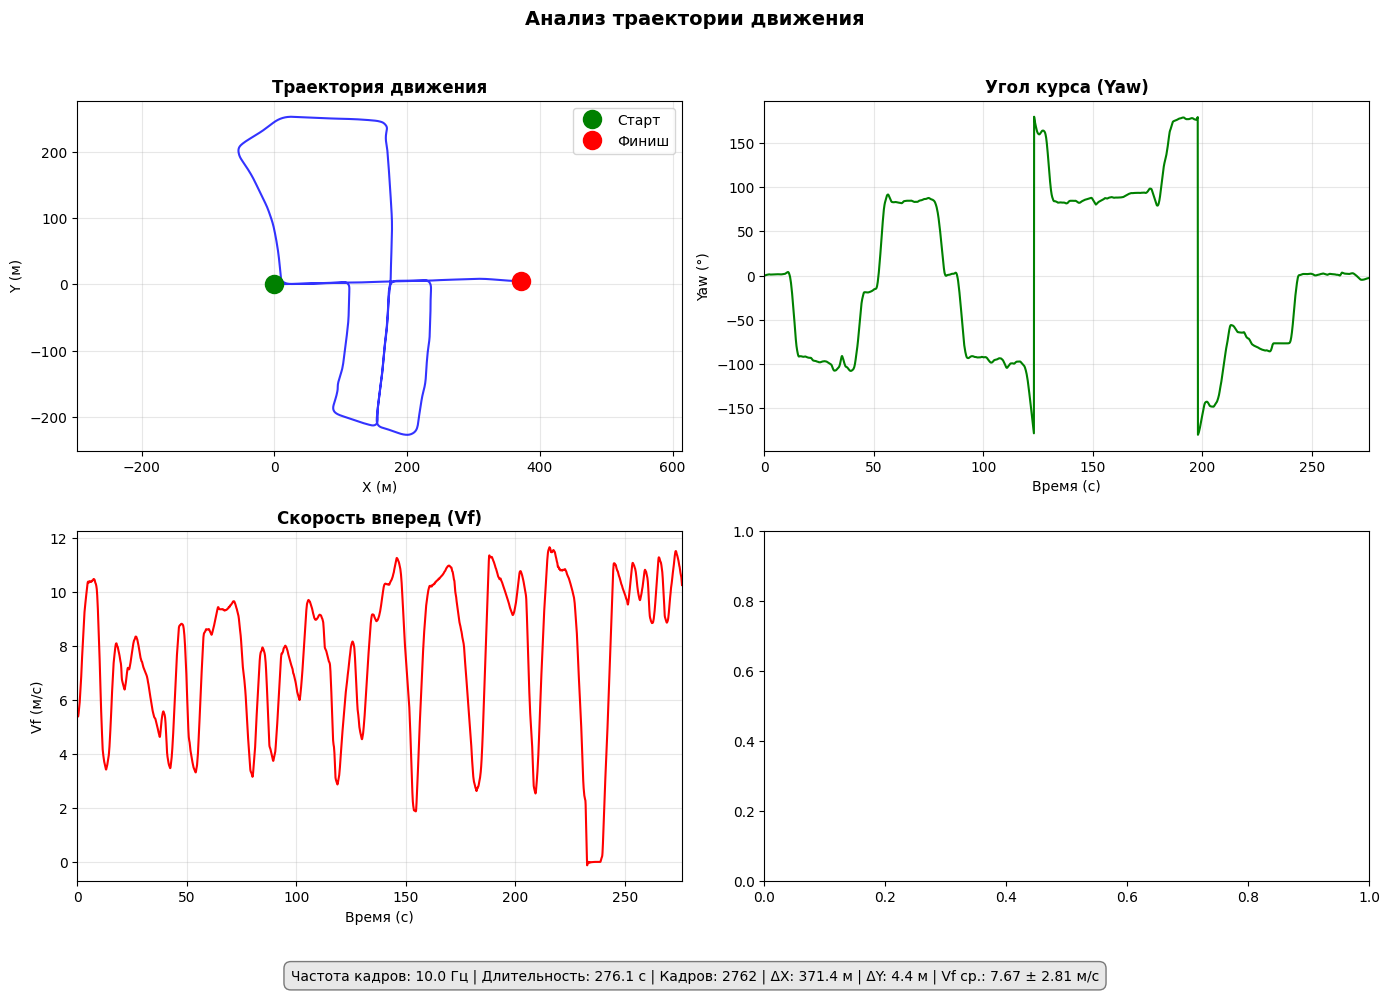

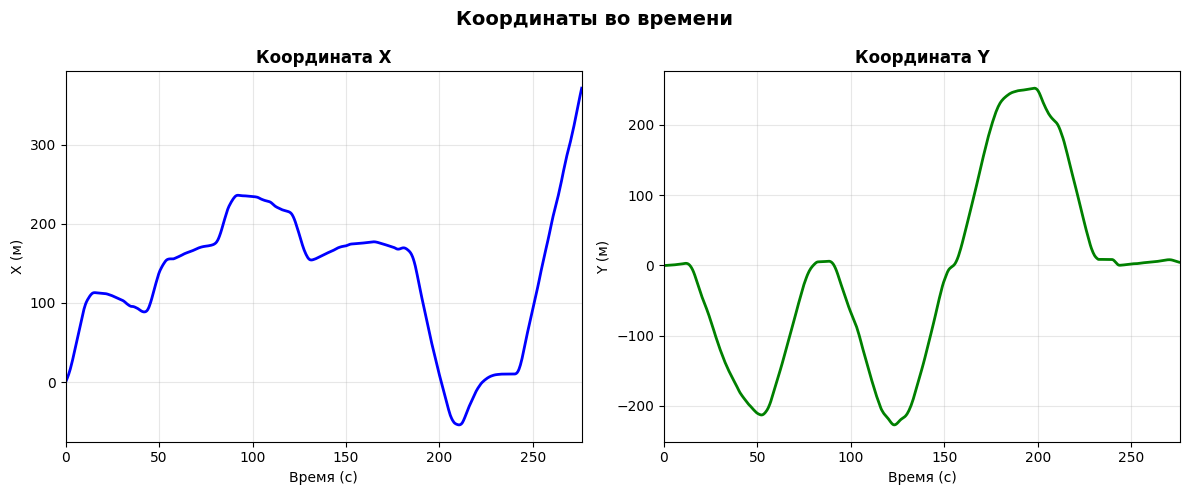

In [ ]:
plot_trajectory(state)

## фи

In [ ]:
#2 способ
def step2_get_ABcords(state_x, mx = 3.724, my = -0.32):
  n = state_x.shape[0]
  cords_AB = np.zeros((n, 3))
  for i in range(n):
    teta = state_x[i, 2]
    #teta = np.arctan2(np.sin(teta), np.cos(teta))

    x_gps = mx * np.cos(teta) - my * np.sin(teta) + state_x[i, 0]
    y_gps = mx * np.sin(teta) + my * np.cos(teta) + state_x[i, 1]
    cords_AB[i] = [x_gps, y_gps, teta]

  return cords_AB

def step2_get_Bcar(cords_A, state_x, mx = 3.724, my = -0.32):
  n = cords_A.shape[0]
  cords_B = np.zeros((n, 2))
  for i in range(1, n):
    teta = cords_A[i-1, 2]
    x_g = cords_A[i-1, 0]
    y_g = cords_A[i-1, 1]
    x_gps = cords_A[i, 0]
    y_gps = cords_A[i, 1]
    # переводим координаты В в систему car_A
    x_car = (x_gps - x_g)* np.cos(teta) + (y_gps - y_g)* np.sin(teta)
    y_car = - (x_gps - x_g) * np.sin(teta) + (y_gps - y_g) * np.cos(teta)
    # считаем дельты координат
    cords_B[i-1] = [x_car, y_car]

  return cords_B

def step3_get_phi5(cords_B, l_car, p):
  n = cords_B.shape[0]
  arr_phi = np.zeros(n)
  for i in range(n-1):
    dx_new = cords_B[i, 0]
    dy_new = cords_B[i, 1]

    phi = np.arctan2((2 * dy_new * l_car), (dy_new**2 + 2 * dx_new * p + dx_new**2))
    arr_phi[i] = phi
  return arr_phi

In [ ]:
l_car = 2.71
p = 0.965 + 2.71 - l_car

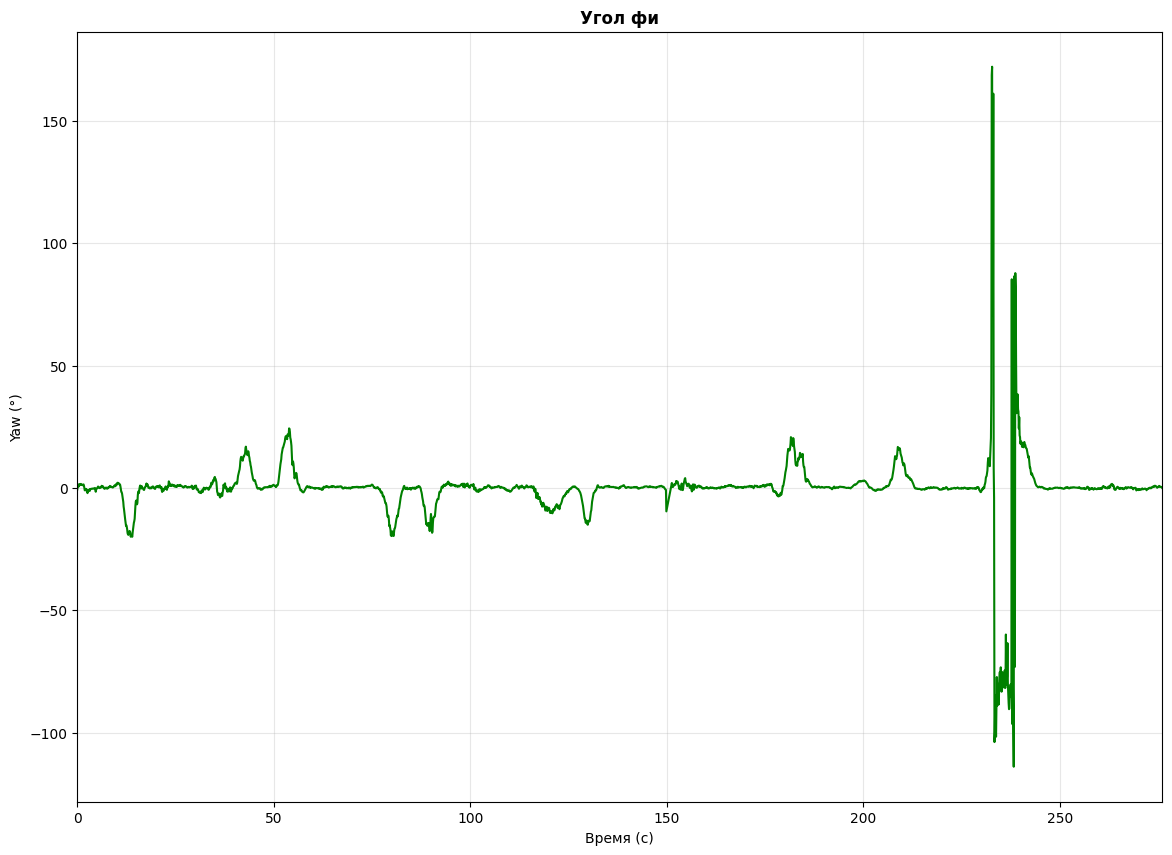

In [ ]:
#2 способ
cords_AB = step2_get_ABcords(state_X, p + 0.05, -0.32)
cords_B = step2_get_Bcar(cords_AB, state_X, p + 0.05, -0.32)
arr_phi = step3_get_phi5(cords_B, l_car, p)

#построим угол

time_axis = np.arange(state_X.shape[0]) / 10  # Время в секундах

# Угол фи (yaw) во времени
yaw_deg = np.degrees(arr_phi)  # Конвертация радиан в градусы

plt.figure(figsize=(14, 10))
plt.plot(time_axis, yaw_deg, 'g-', linewidth=1.5)
plt.title('Угол фи', fontsize=12, fontweight='bold')
plt.xlabel('Время (с)', fontsize=10)
plt.ylabel('Yaw (°)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, time_axis[-1])
plt.show()

In [ ]:
n = state_X.shape[0]
all_states = np.zeros((n, 5))
all_states[:, :2] = state_X[:, :2]
all_states[:, 2] = state_X[:, 2]
#all_states[:, 2] = cords_AB[:, 2]
all_states[:, 3] = state['vf']
all_states[:, 4] = arr_phi

In [ ]:
#plot_vehicle_states_custom(all_states[:])

### способ 1, 3

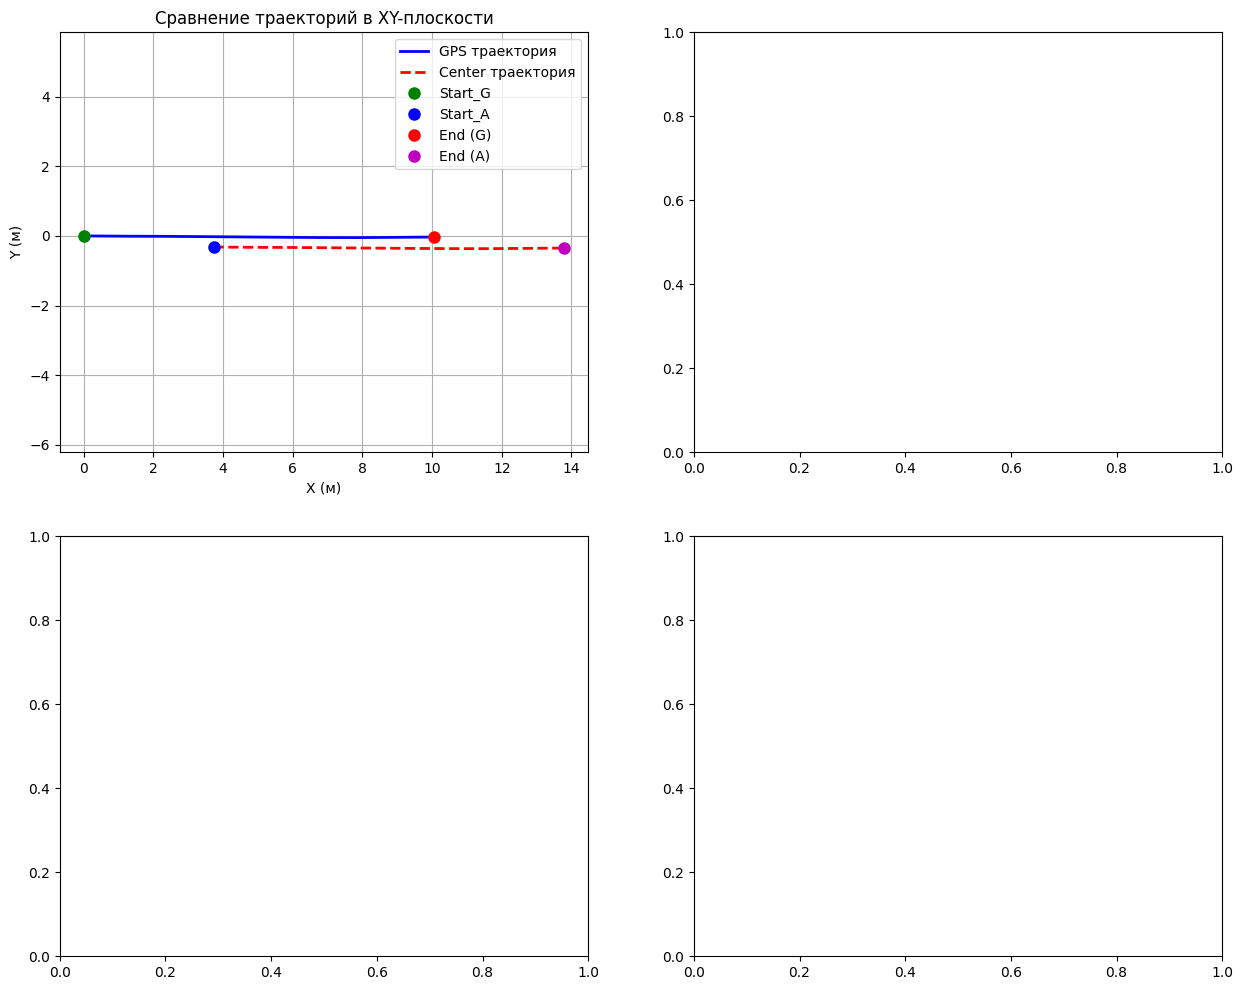

In [ ]:
plot_comparison(state_X[:10], cords_AB[:10])

In [ ]:
#3 способ
def get_phi_basic_way(state_x, l_car, p):
  n = state_x.shape[0]
  arr_phi = np.zeros(n)
  for i in range(n-1):
    dx_new = state_x[i+1, 0] - state_x[i, 0]
    dy_new = state_x[i+1, 1] - state_x[i, 1]

    arr_phi[i] = np.arctan2((2 * dy_new * l_car), (dy_new**2 + 2 * dx_new * p + dx_new**2))
  return arr_phi

arr_phi = get_phi_basic_way(state_X, l_car, p)

In [ ]:
#1 способ

def step3_get_phi(cords_AB, l_car, p):
  n = cords_AB.shape[0]
  arr_phi = np.zeros(n)
  for i in range(n-1):
    dx = cords_AB[i+1, 0] - cords_AB[i, 0]
    dy = cords_AB[i+1, 1] - cords_AB[i, 1]

    AB = np.sqrt(dx**2 + dy**2)

    alpha1 = cords_AB[i, 2] + np.arctan(dy / dx)
    dx_new = AB * np.cos(alpha1)

    alpha2 = np.radians(90) - alpha1
    dy_new = AB * np.cos(alpha2)

    phi = np.arctan((2 * dy_new * l_car) / (dy_new**2 + 2 * dx_new * p + dx_new**2))
    arr_phi[i] = phi

  return arr_phi

#1 способ
cords_AB = step2_get_ABcords(state_X, p + 0.05, -0.32)

arr_phi = step3_get_phi(cords_AB, l_car, p)

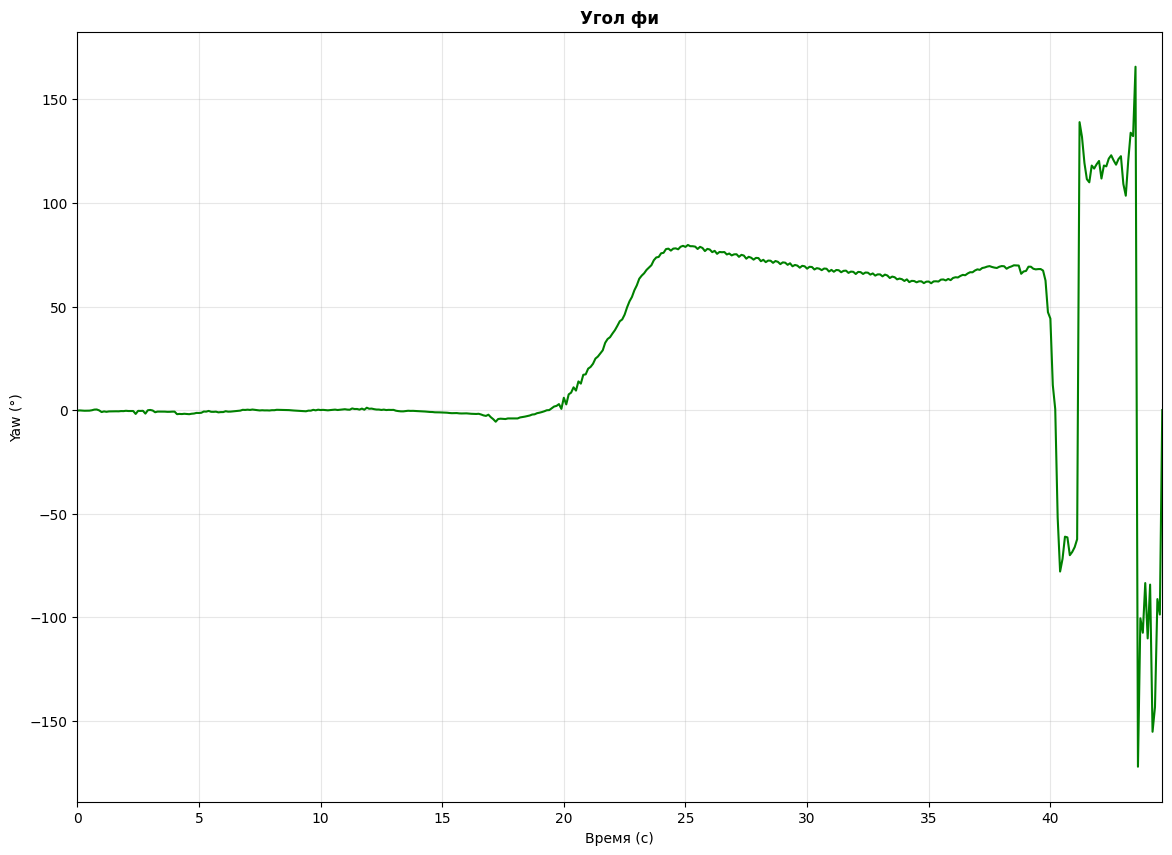

In [ ]:
time_axis = np.arange(state_X.shape[0]) / 10  # Время в секундах

# Угол фи (yaw) во времени
yaw_deg = np.degrees(arr_phi)  # Конвертация радиан в градусы

plt.figure(figsize=(14, 10))
plt.plot(time_axis, yaw_deg, 'g-', linewidth=1.5)
plt.title('Угол фи', fontsize=12, fontweight='bold')
plt.xlabel('Время (с)', fontsize=10)
plt.ylabel('Yaw (°)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, time_axis[-1])
plt.show()

In [ ]:
all_states[0]

array([ 3.72400000e+00, -3.20000000e-01, -3.06091581e-18,  1.15027826e+01,
        7.03916377e-03])

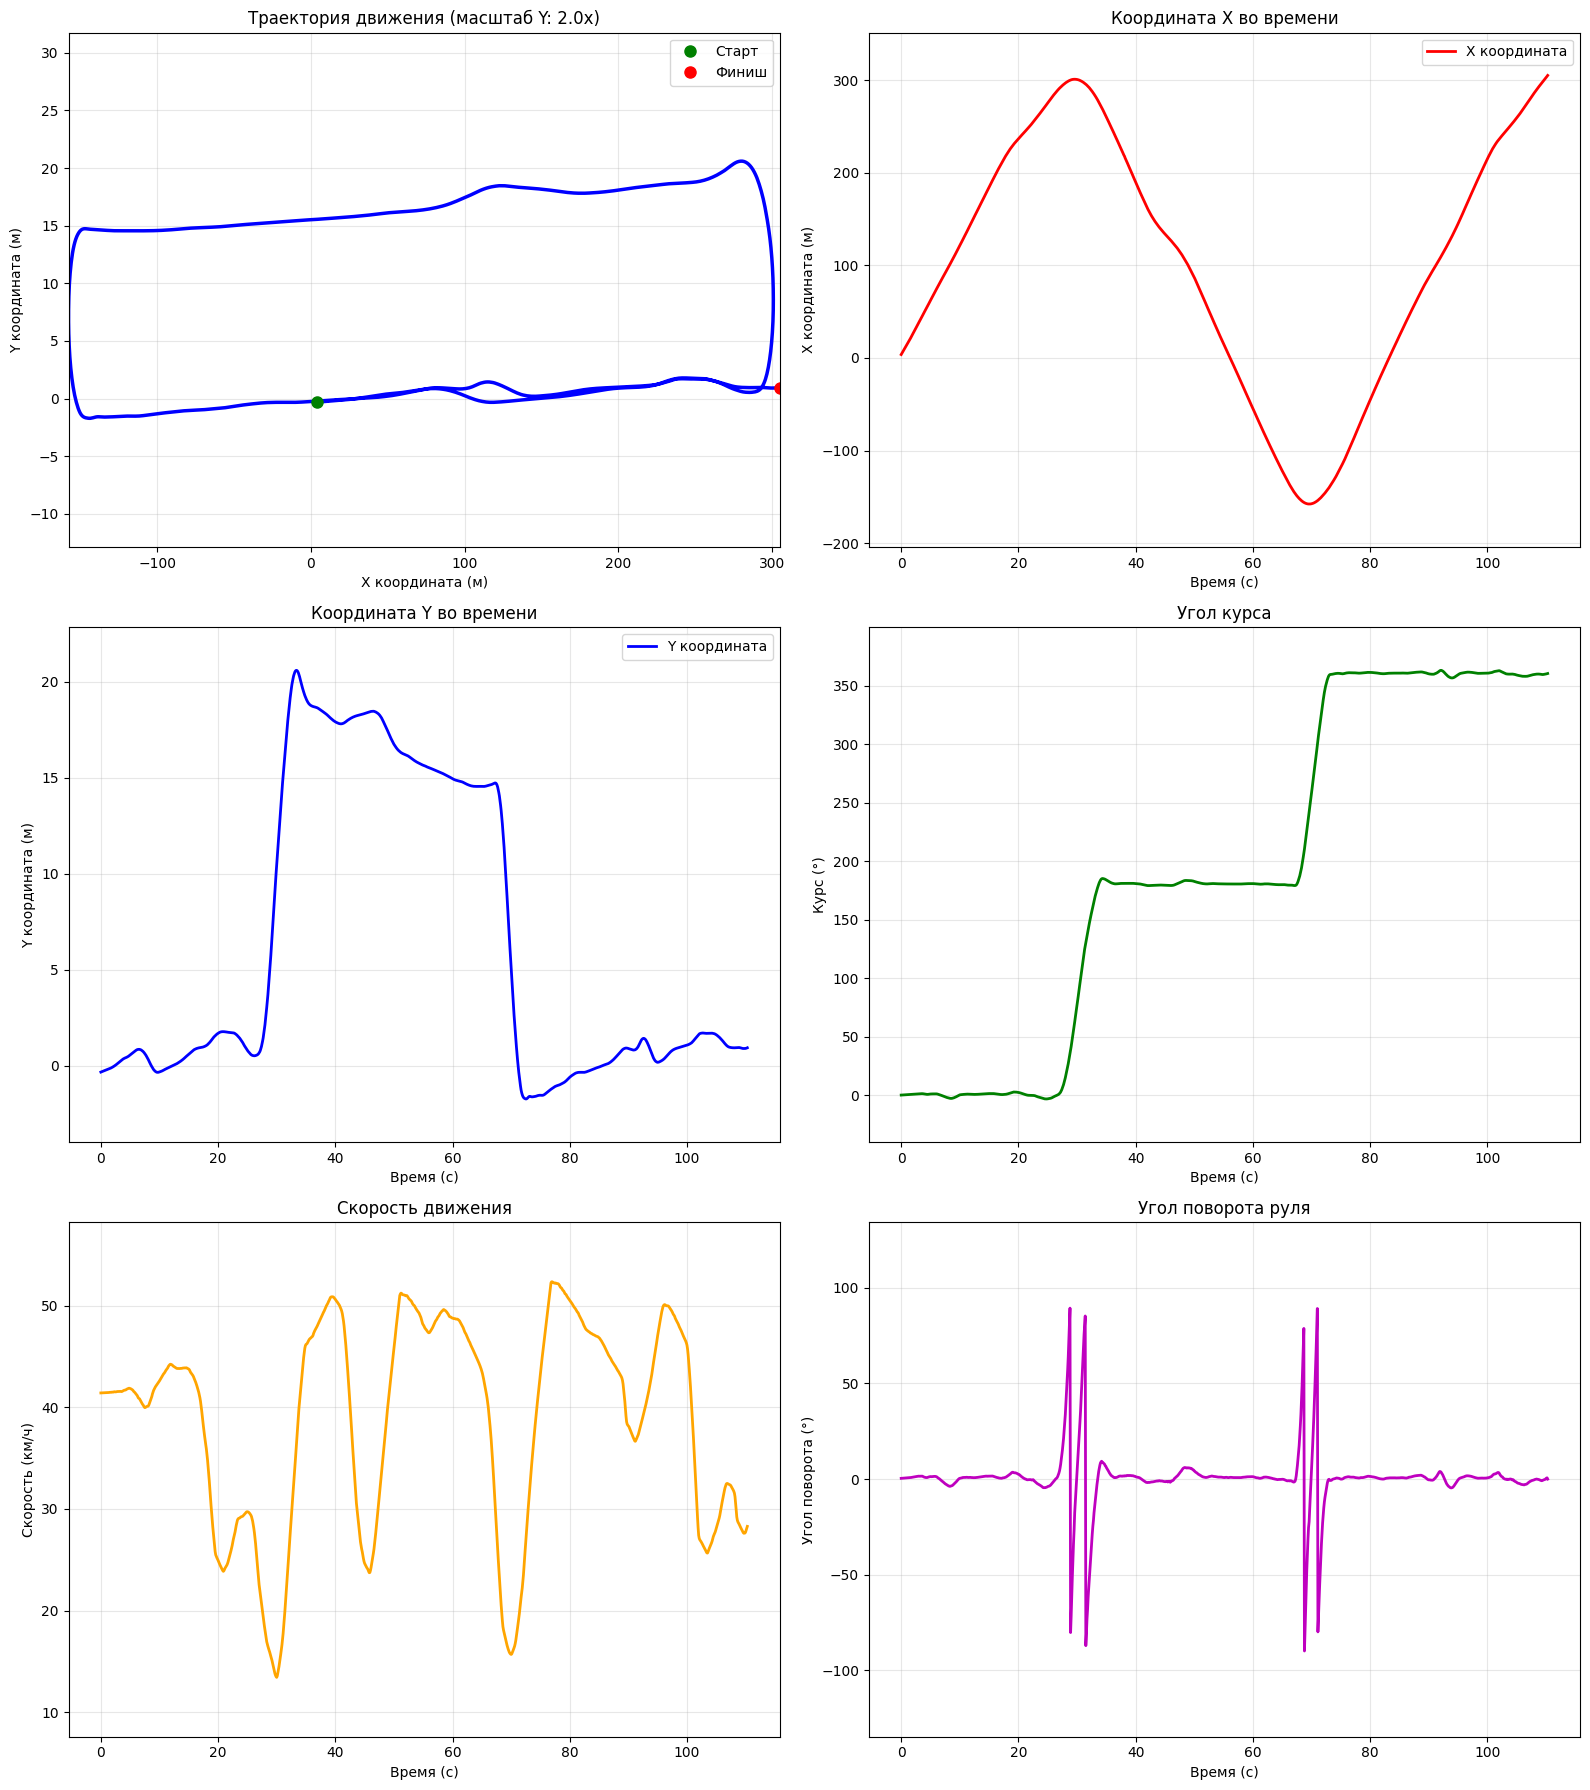

In [ ]:
plot_vehicle_states_custom(all_states)

## modeling

Размерность входных данных: (2762, 5)
Размерность выходной траектории: (2762, 5)
Начальная точка: [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  5.45013931e+00
 -3.49581340e-03]
Конечная точка: [6.44183098e+02 2.79350748e+02 1.62612508e-01 1.03613090e+01
 1.17597739e-02]


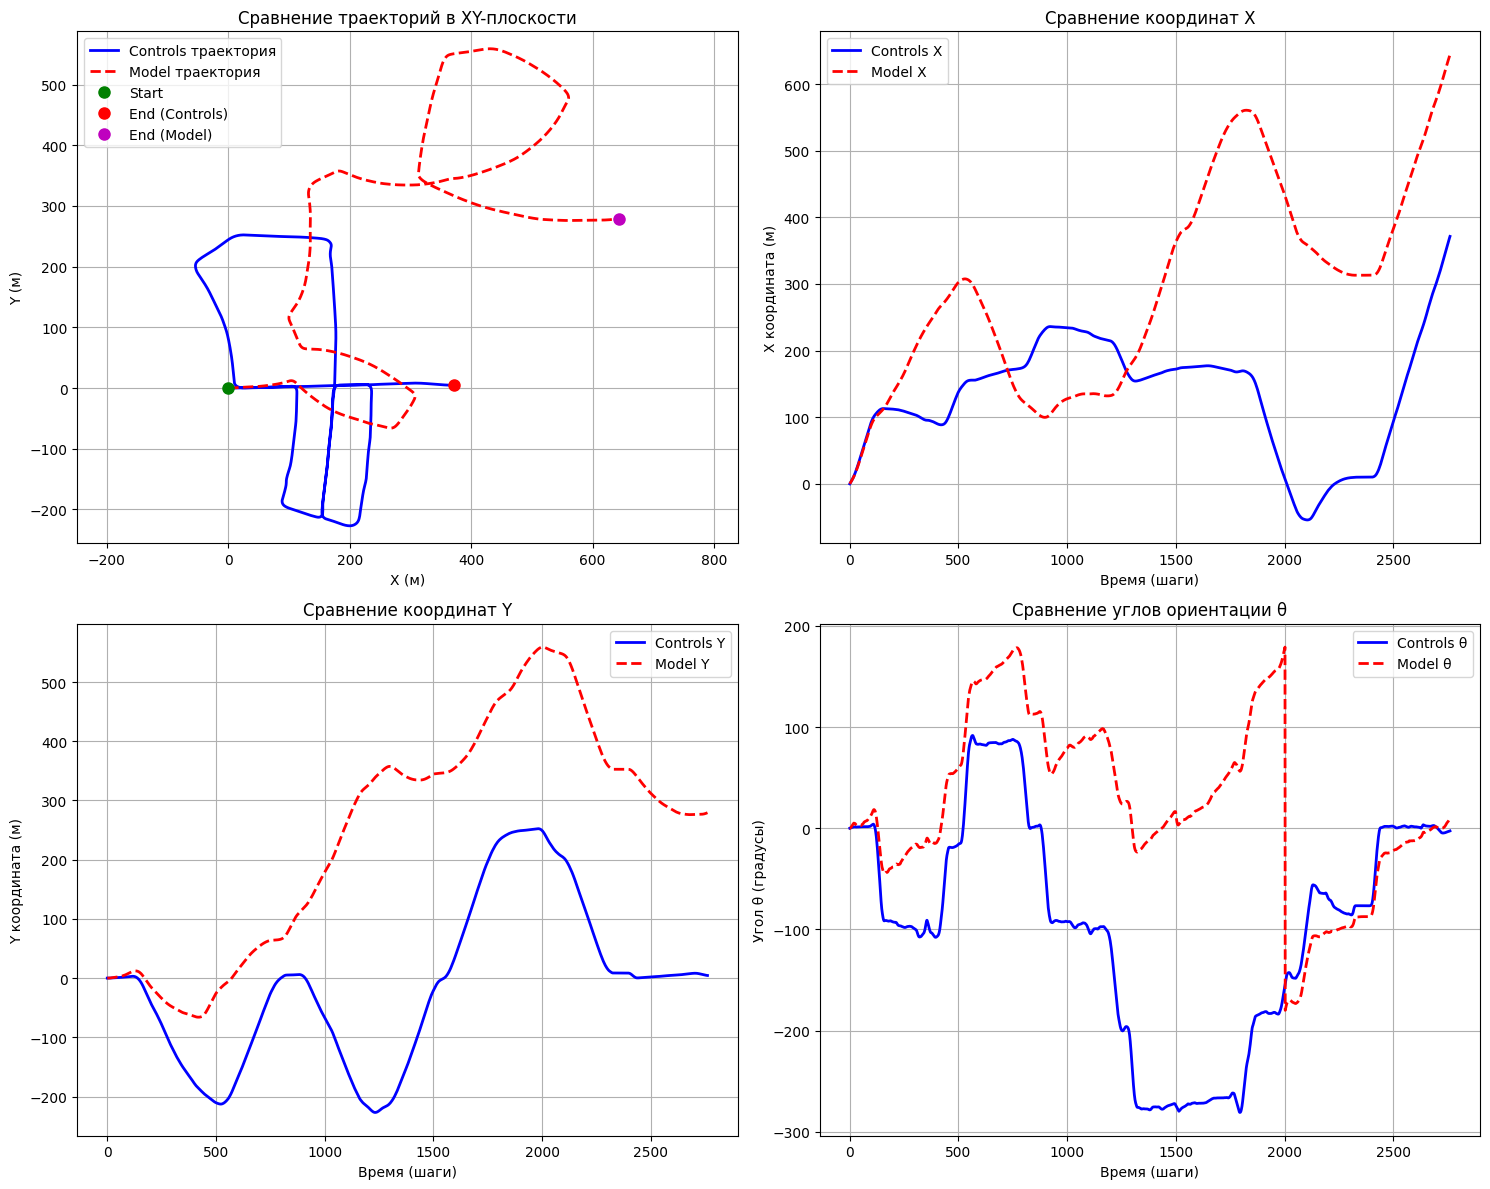

МЕТРИКИ СРАВНЕНИЯ ТРАЕКТОРИЙ
RMSE по X: 237.4930 м
RMSE по Y: 297.1504 м
Общий RMSE: 380.3962 м
Максимальная ошибка по X: 425.5128 м
Максимальная ошибка по Y: 571.9332 м
Конечная позиция Controls: (371.37, 4.43) м
Конечная позиция Model:    (644.18, 279.35) м
Расстояние между конечными точками: 387.3086 м


In [ ]:
# Моделируем траекторию
X_state_model = simulate_trajectory_from_controls(all_states, l_car=l_car, dt=0.1)

print(f"Размерность входных данных: {all_states.shape}")
print(f"Размерность выходной траектории: {X_state_model.shape}")
print(f"Начальная точка: {X_state_model[0]}")
print(f"Конечная точка: {X_state_model[-1]}")

# Визуализируем результаты
plot_trajectory_comparison(all_states, X_state_model)

In [ ]:
# Scale Phi
scale_phi = 1.2
arr_phi_scale = arr_phi.copy()
arr_phi_scale[:200] = arr_phi_scale[:200]
arr_phi_scale[300:670] = arr_phi_scale[300:670] * 1.25
arr_phi_scale[700:] = arr_phi_scale[700:] * 1.4



n = state_X.shape[0]
all_states = np.zeros((n, 5))
all_states[:, :2] = state_X[:, :2]
all_states[:, 2] = state_X[:, 2]
#all_states[:, 2] = cords_AB[:, 2]
all_states[:, 3] = state['vf']
all_states[:, 4] = arr_phi_scale

In [ ]:
# Scale Phi
scale_phi = 0.8
arr_phi_scale = (arr_phi + 0.007) * scale_phi



n = state_X.shape[0]
all_states = np.zeros((n, 5))
all_states[:, :2] = state_X[:, :2]
all_states[:, 2] = state_X[:, 2]
#all_states[:, 2] = cords_AB[:, 2]
all_states[:, 3] = state['vf']
all_states[:, 4] = arr_phi_scale

In [ ]:
X_state_model.shape

(1104, 5)

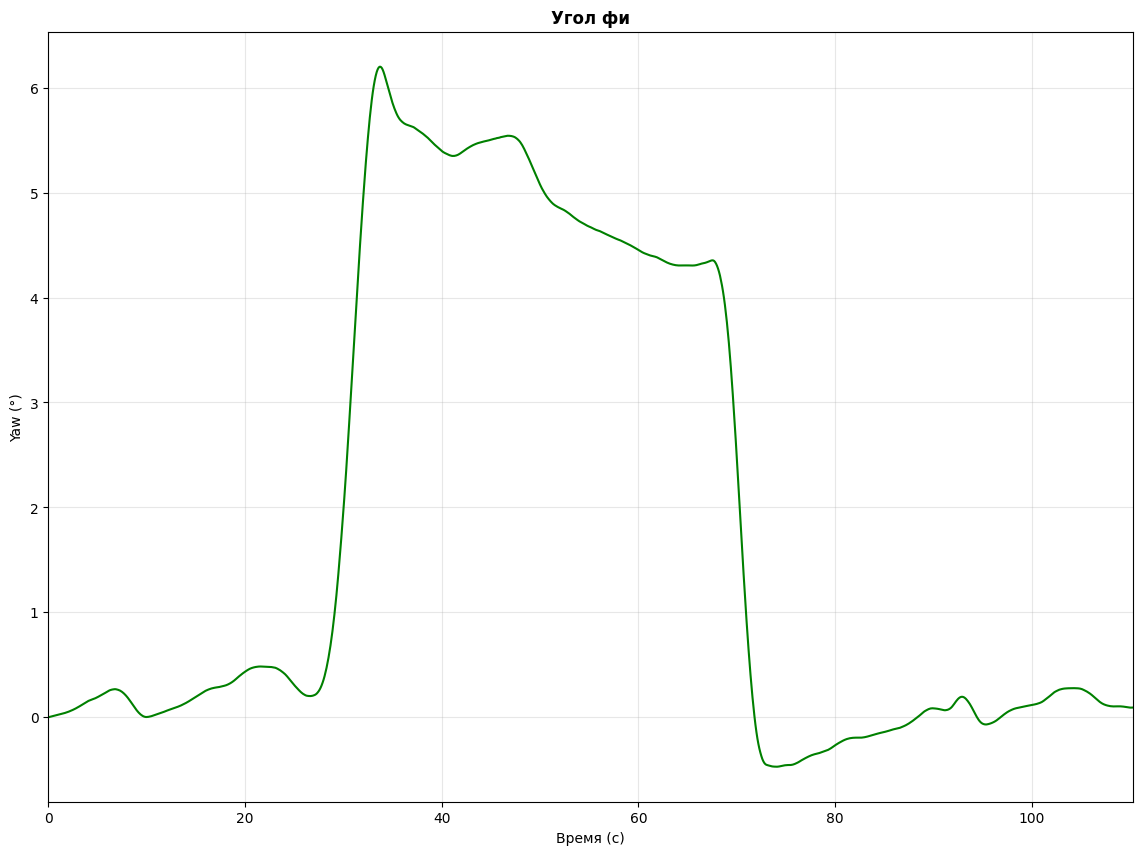

In [ ]:
#построим угол

time_axis = np.arange(state_X.shape[0]) / 10  # Время в секундах

# Угол фи (yaw) во времени

plt.figure(figsize=(14, 10))
plt.plot(time_axis, X_state_model[:, 2], 'g-', linewidth=1.5)
plt.title('Угол фи', fontsize=12, fontweight='bold')
plt.xlabel('Время (с)', fontsize=10)
plt.ylabel('Yaw (°)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, time_axis[-1])
plt.show()